In [86]:
import pandas as pd
import copy
import spacy

import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
nlp = spacy.load('de_core_news_md')

all_party_textes_df = pd.read_parquet("all_parties_text_combined.parquet")
Labled_theses_df = pd.read_csv('wahlomaten_thesen_positionen.csv')

In [88]:
lable_colums_list = Labled_theses_df.columns[1:].tolist()

replace_dict = {
    'spd'   :   'SPD', 
    'cdu'   :   'CDU / CSU', 
    'gruene':   'GRÜNE', 
    'afd'   :   'AfD',
    'fdp'   :   'FDP', 
    'linke' :   'Die Linke'
}

all_party_textes_df['Party'] = all_party_textes_df['Party'].replace(replace_dict)
del replace_dict

In [89]:

parties_list = all_party_textes_df['Party'].unique().tolist()
Labled_theses_list = Labled_theses_df['These'].tolist()
predicted_theses_df = copy.deepcopy(Labled_theses_df)

In [90]:
parties_list

['SPD', 'CDU / CSU', 'GRÜNE', 'AfD', 'FDP', 'Die Linke']

In [91]:
all_party_textes_df['Chapter'] = all_party_textes_df['Chapter'].fillna('-')

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


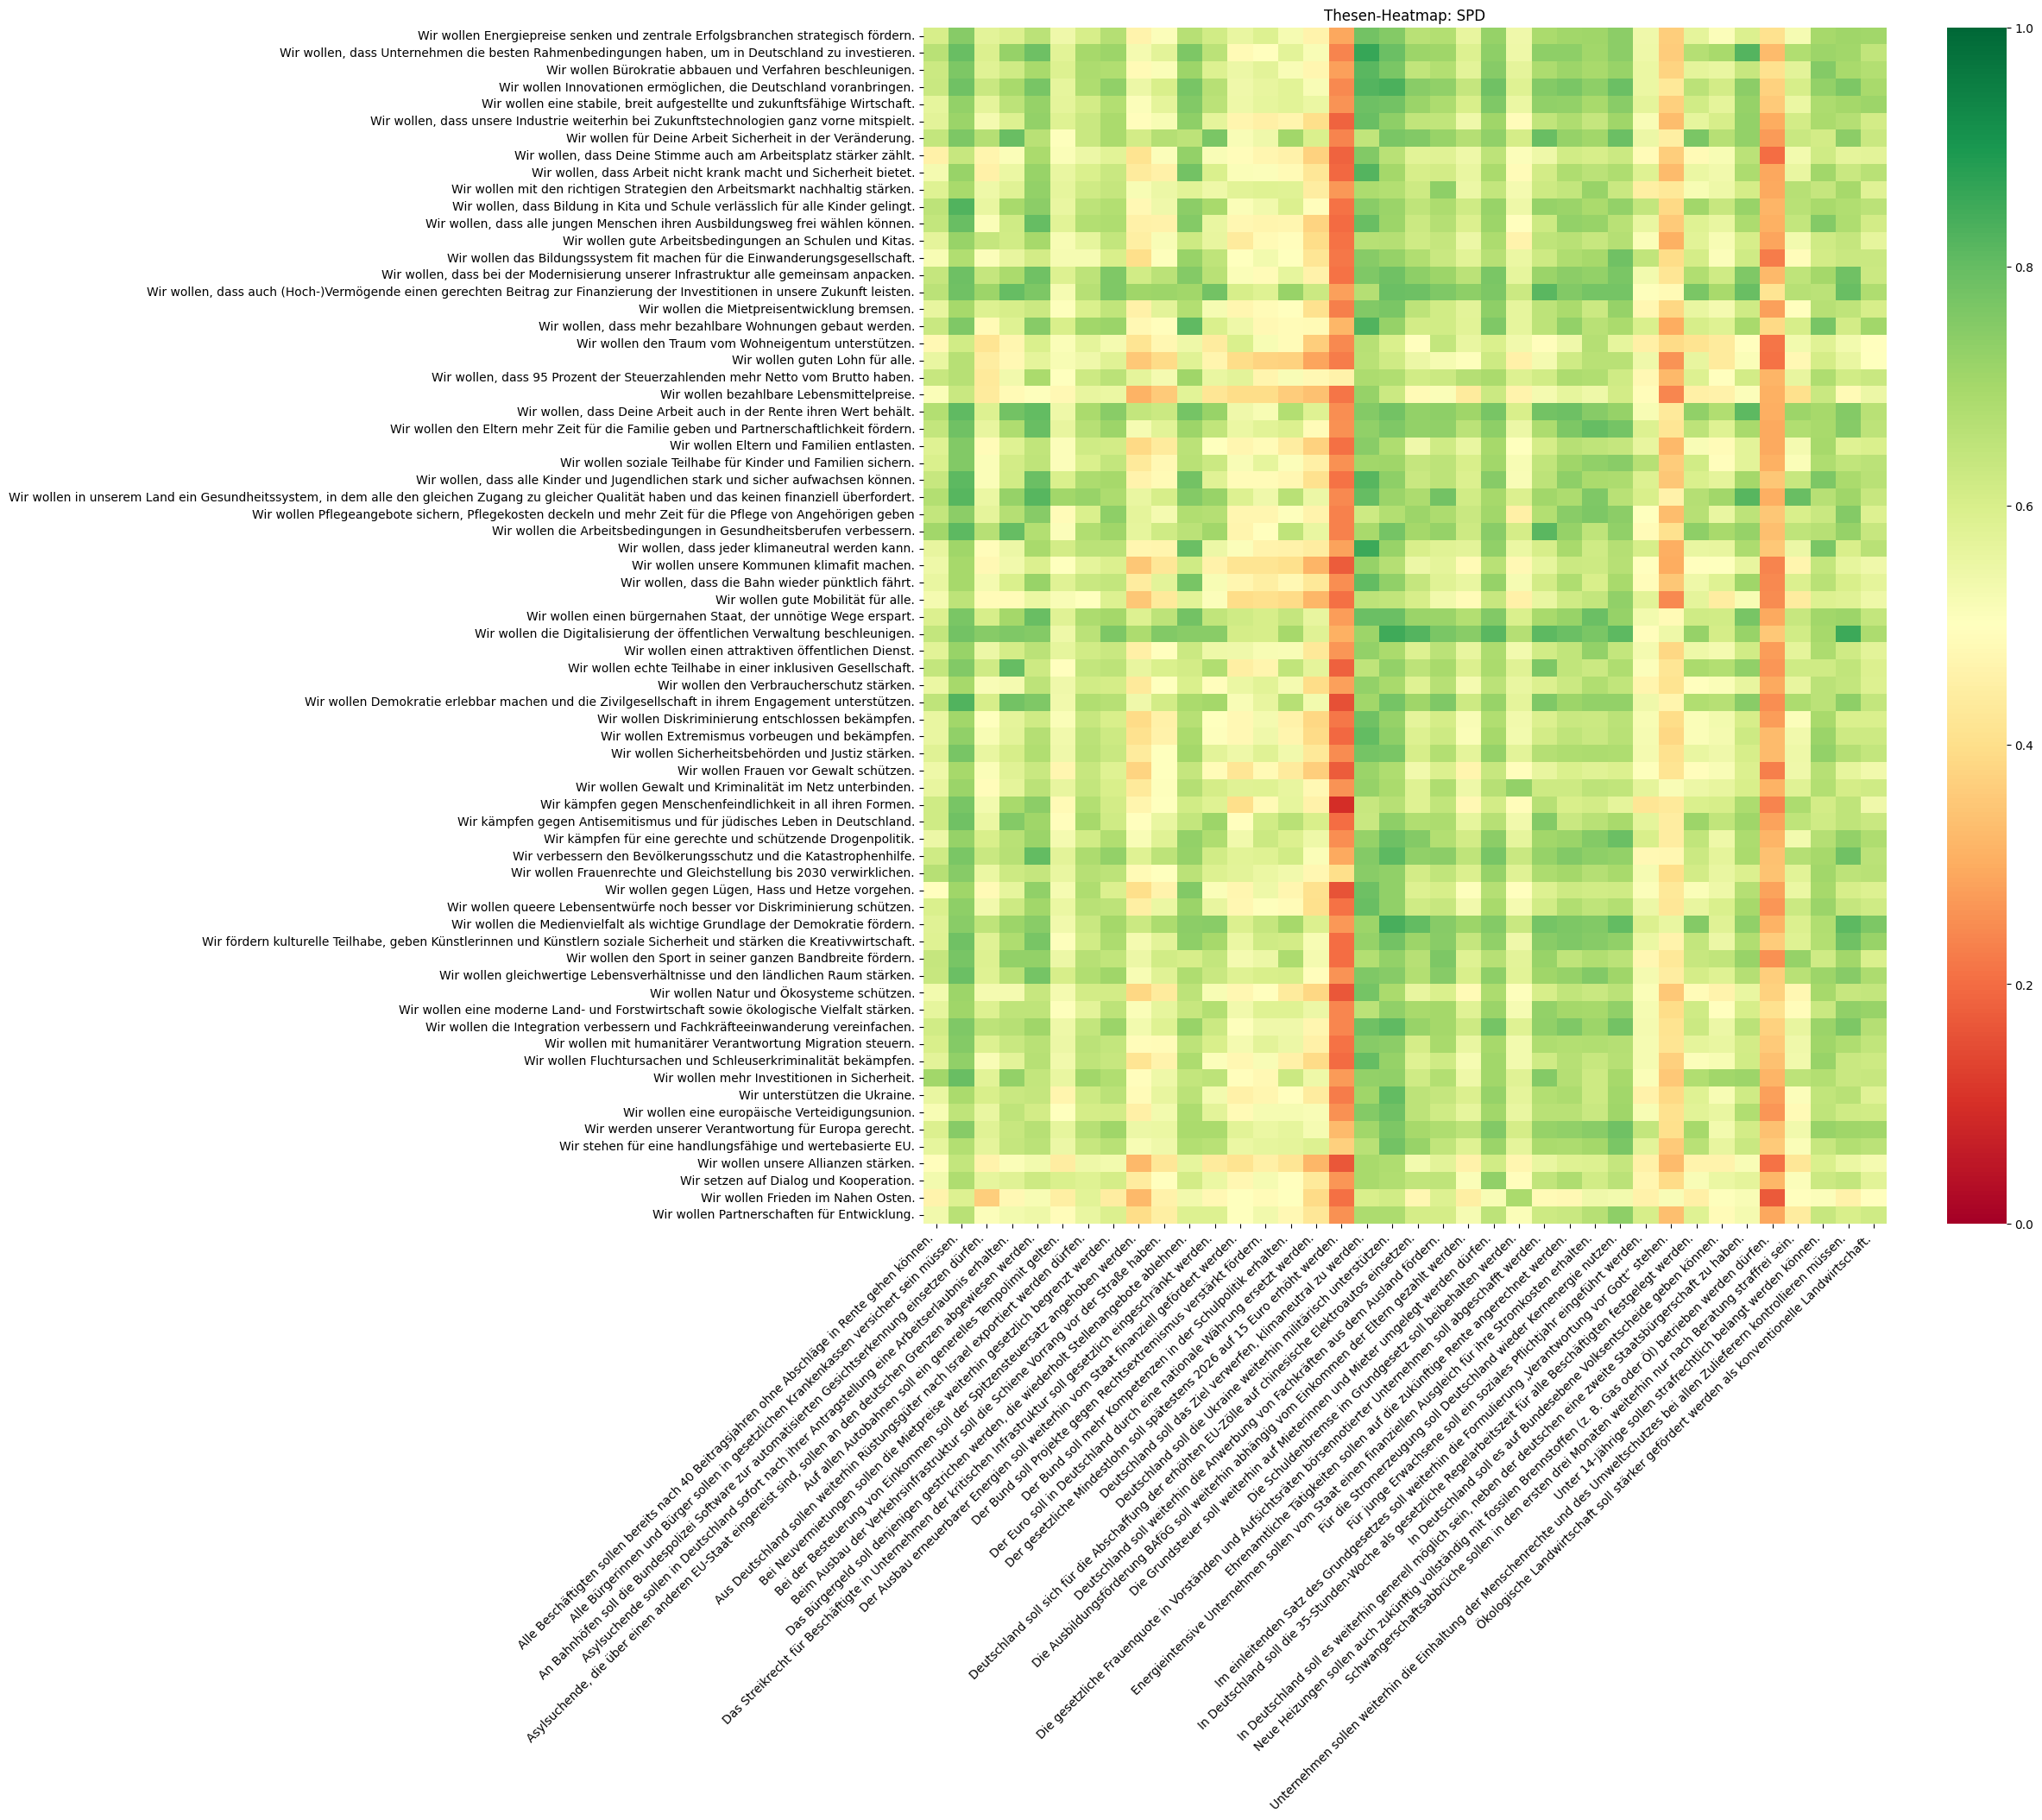

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


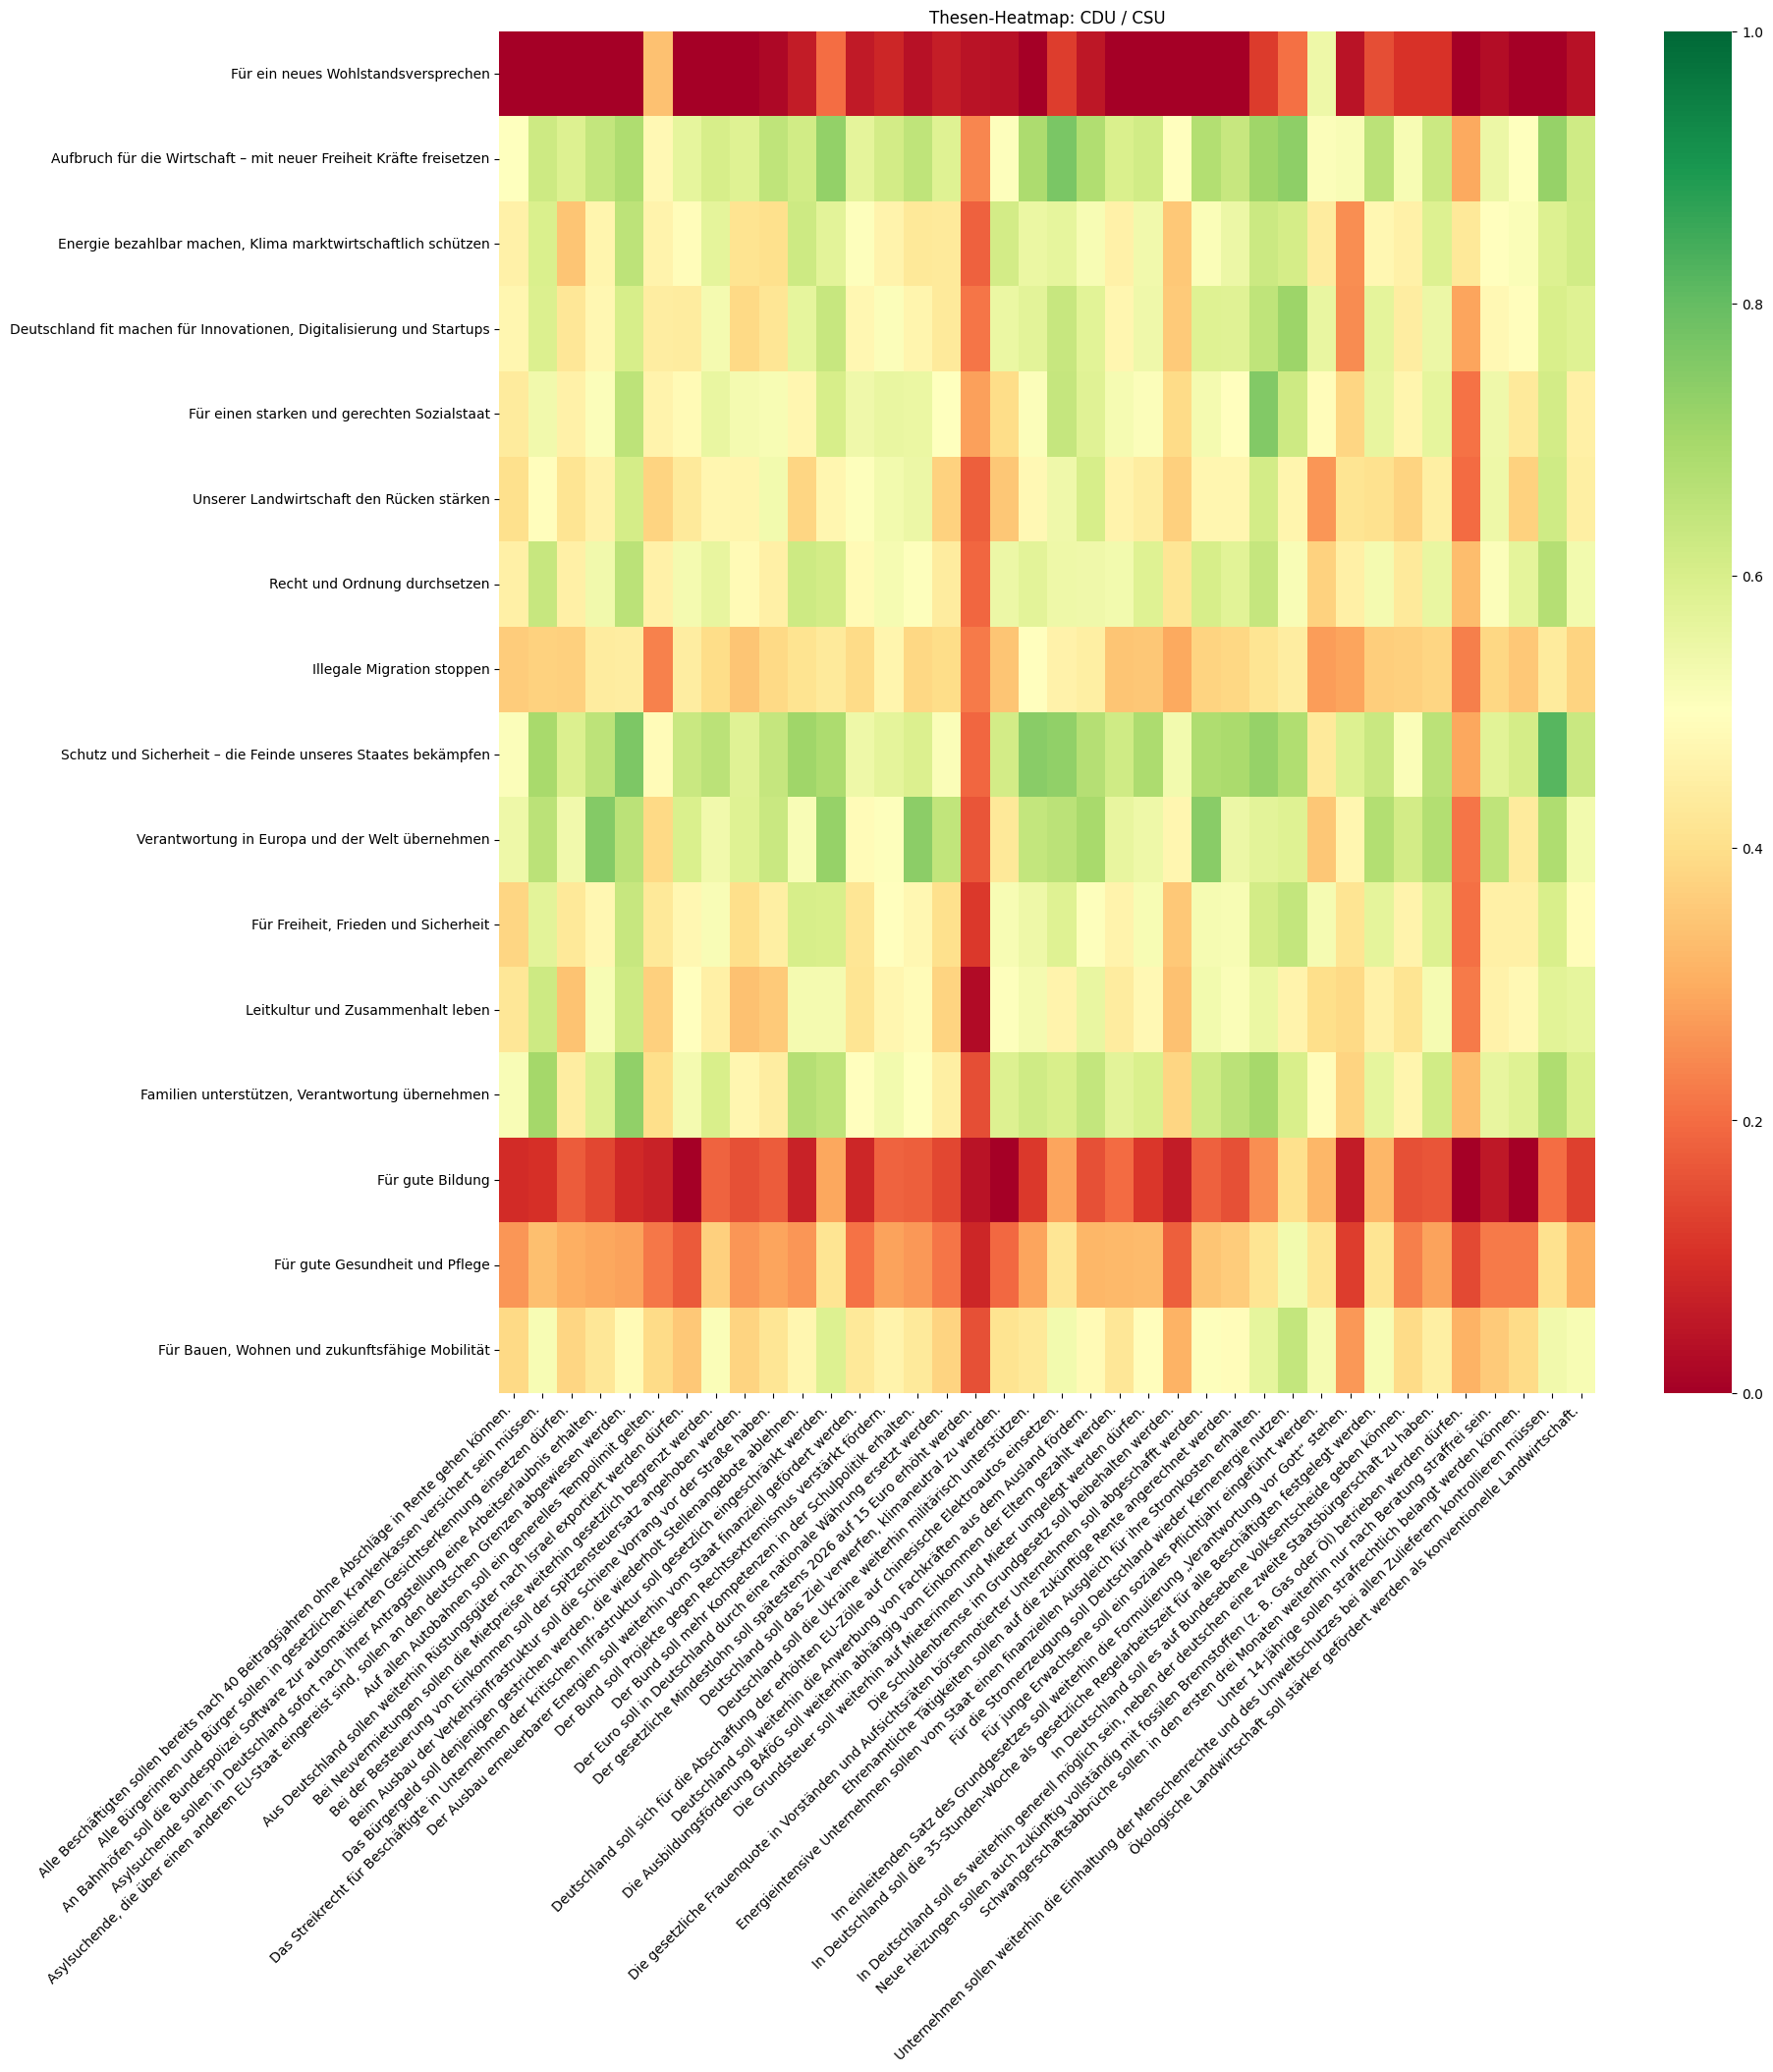

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


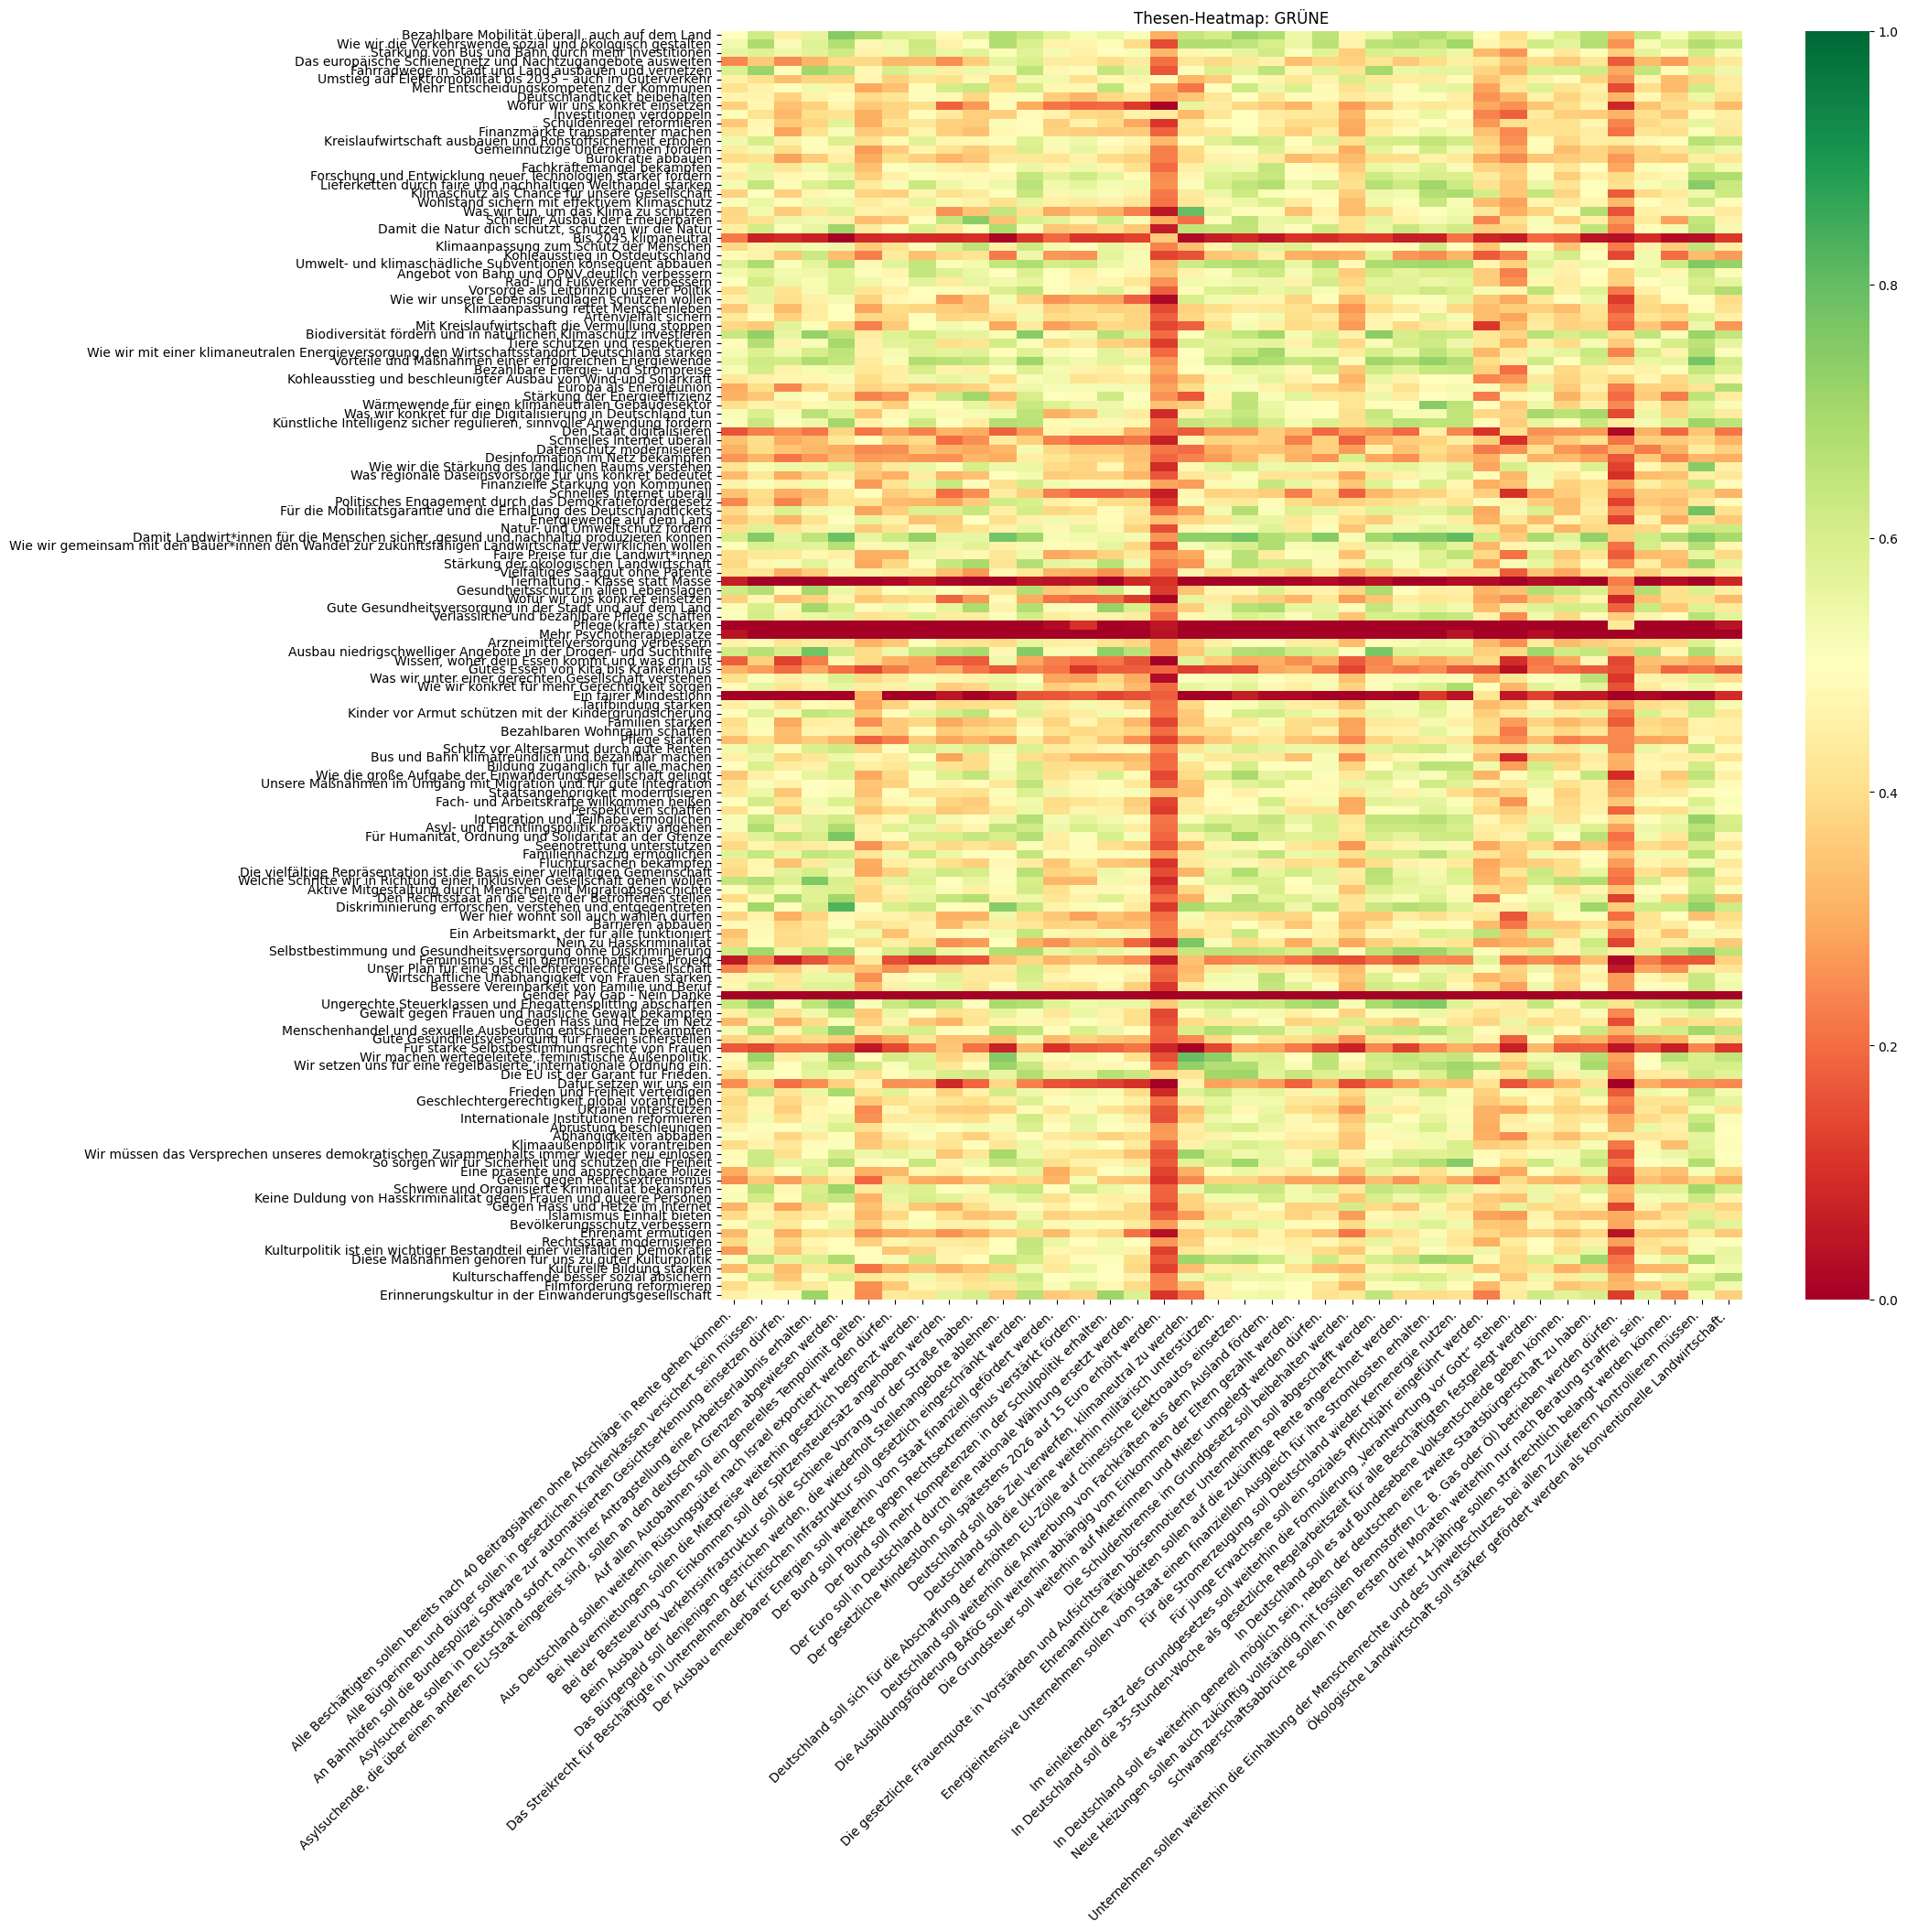

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:13: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)


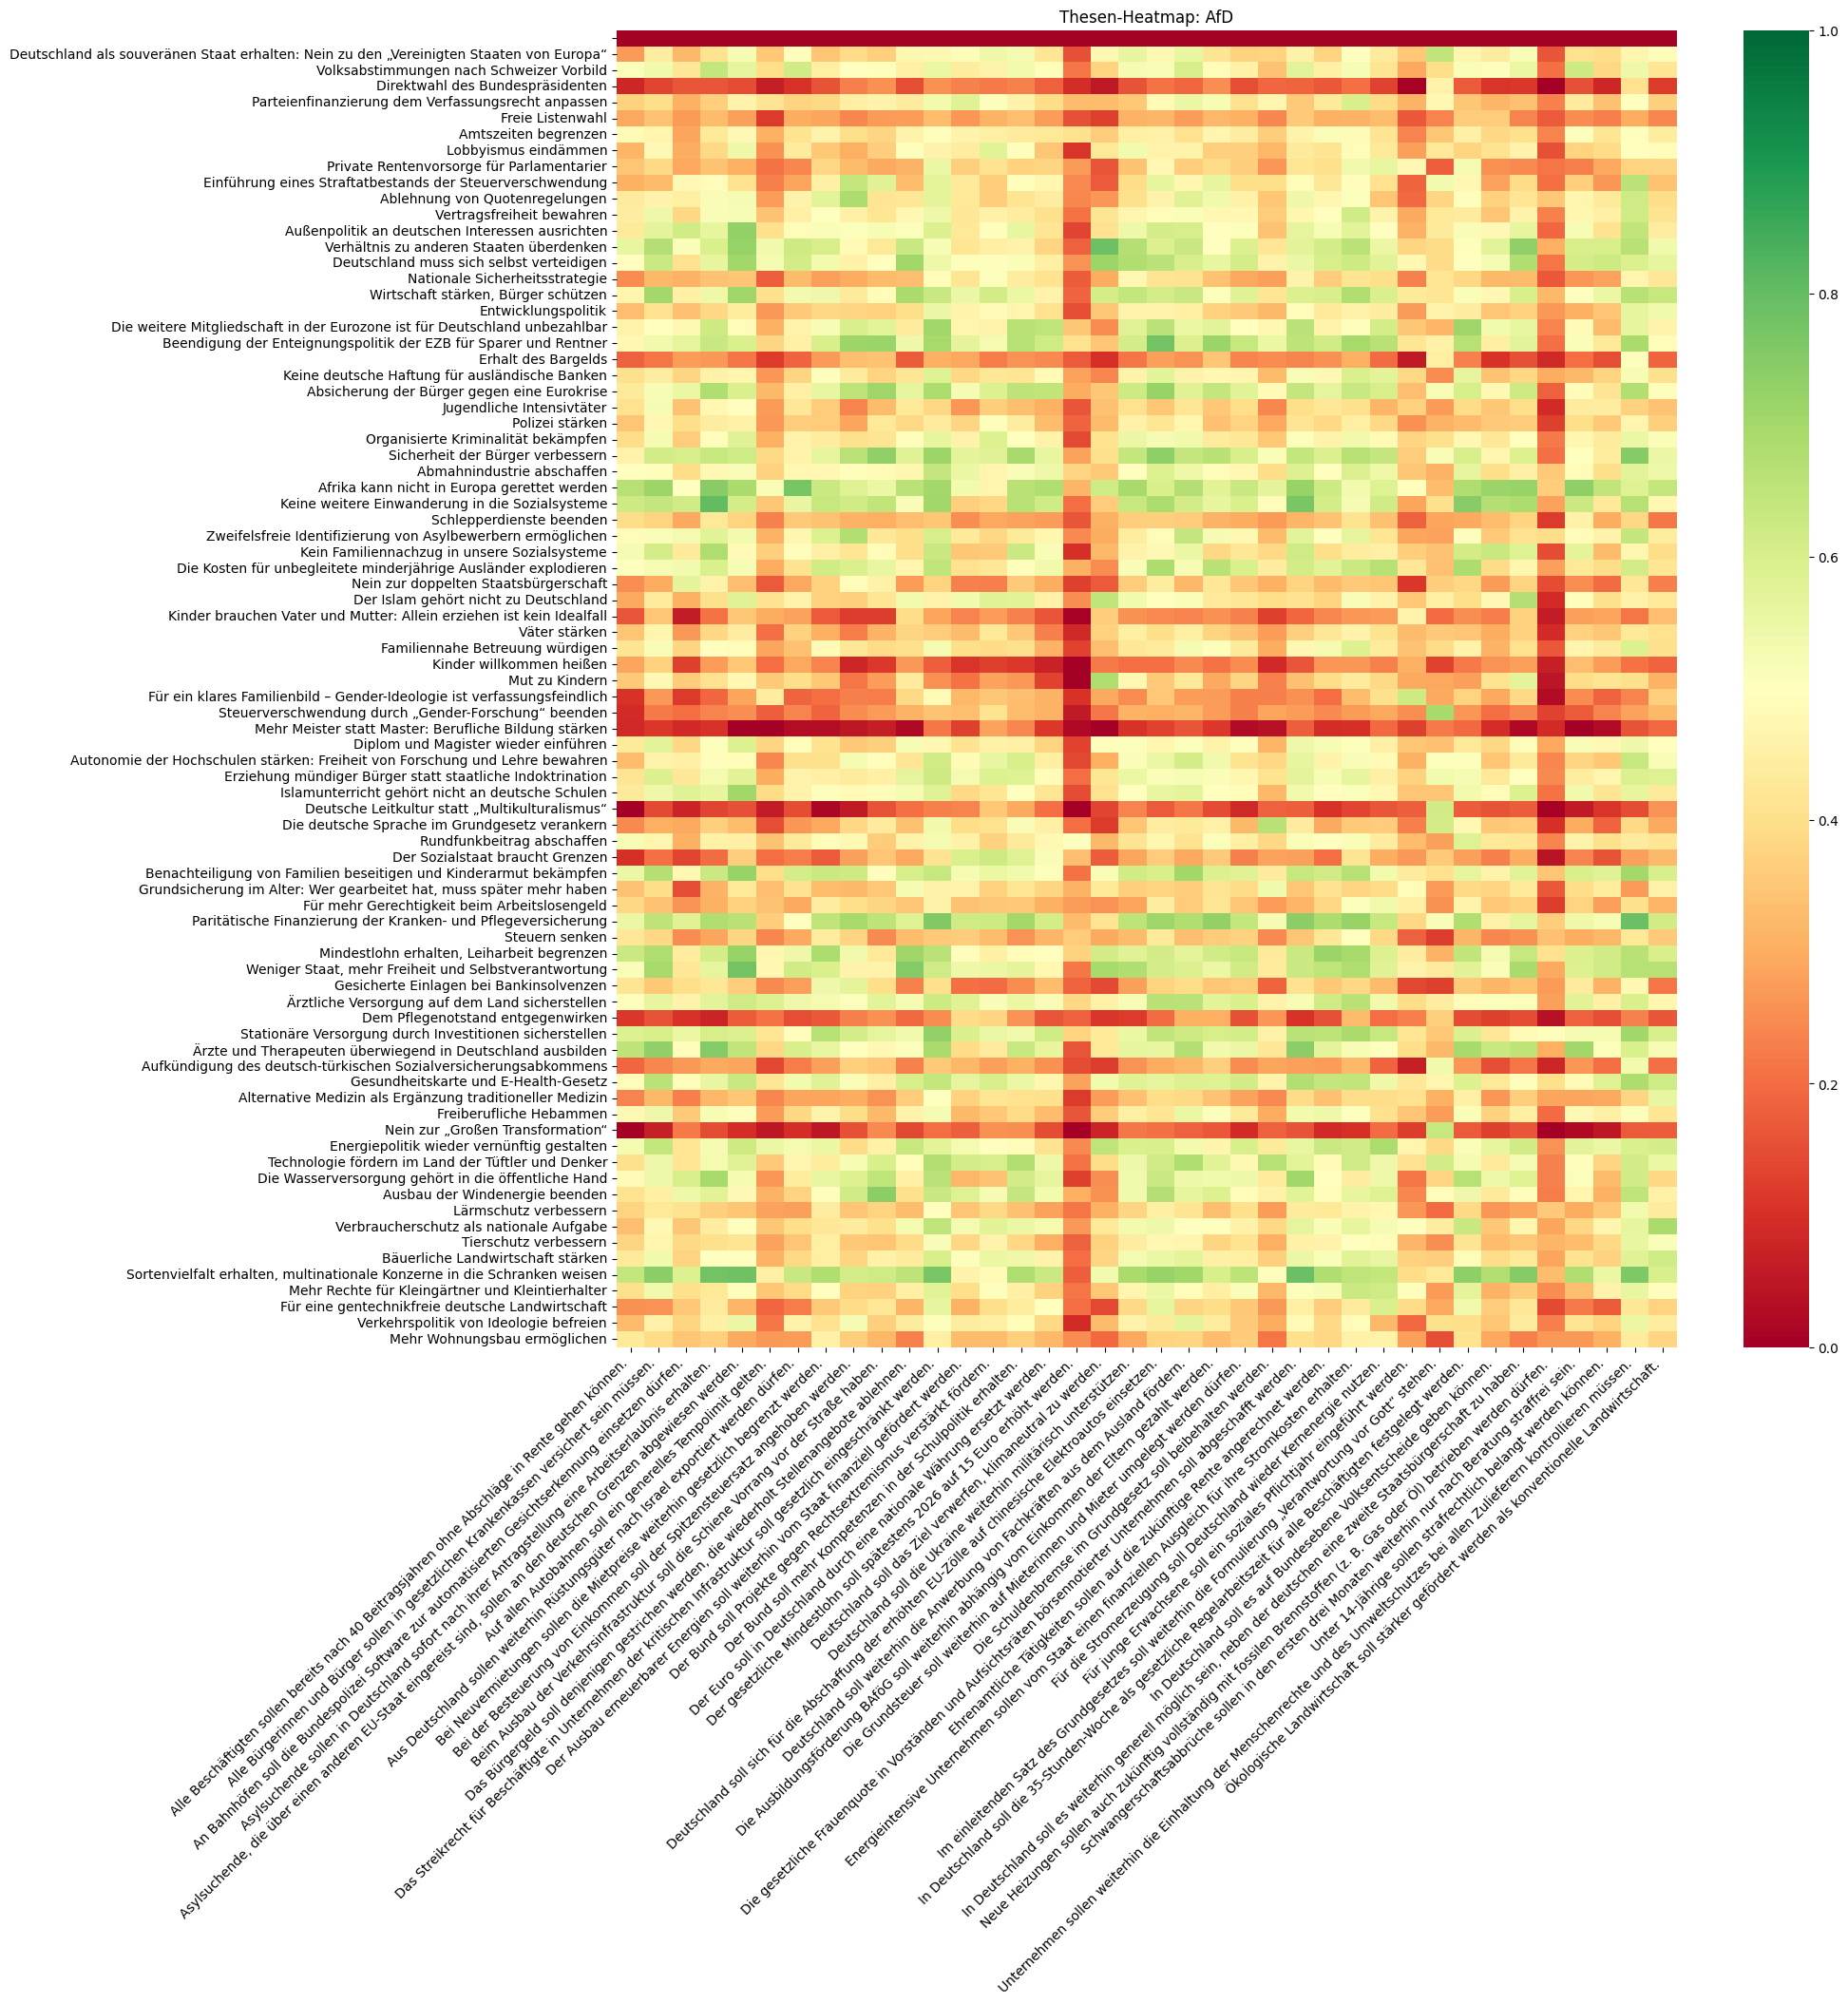

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


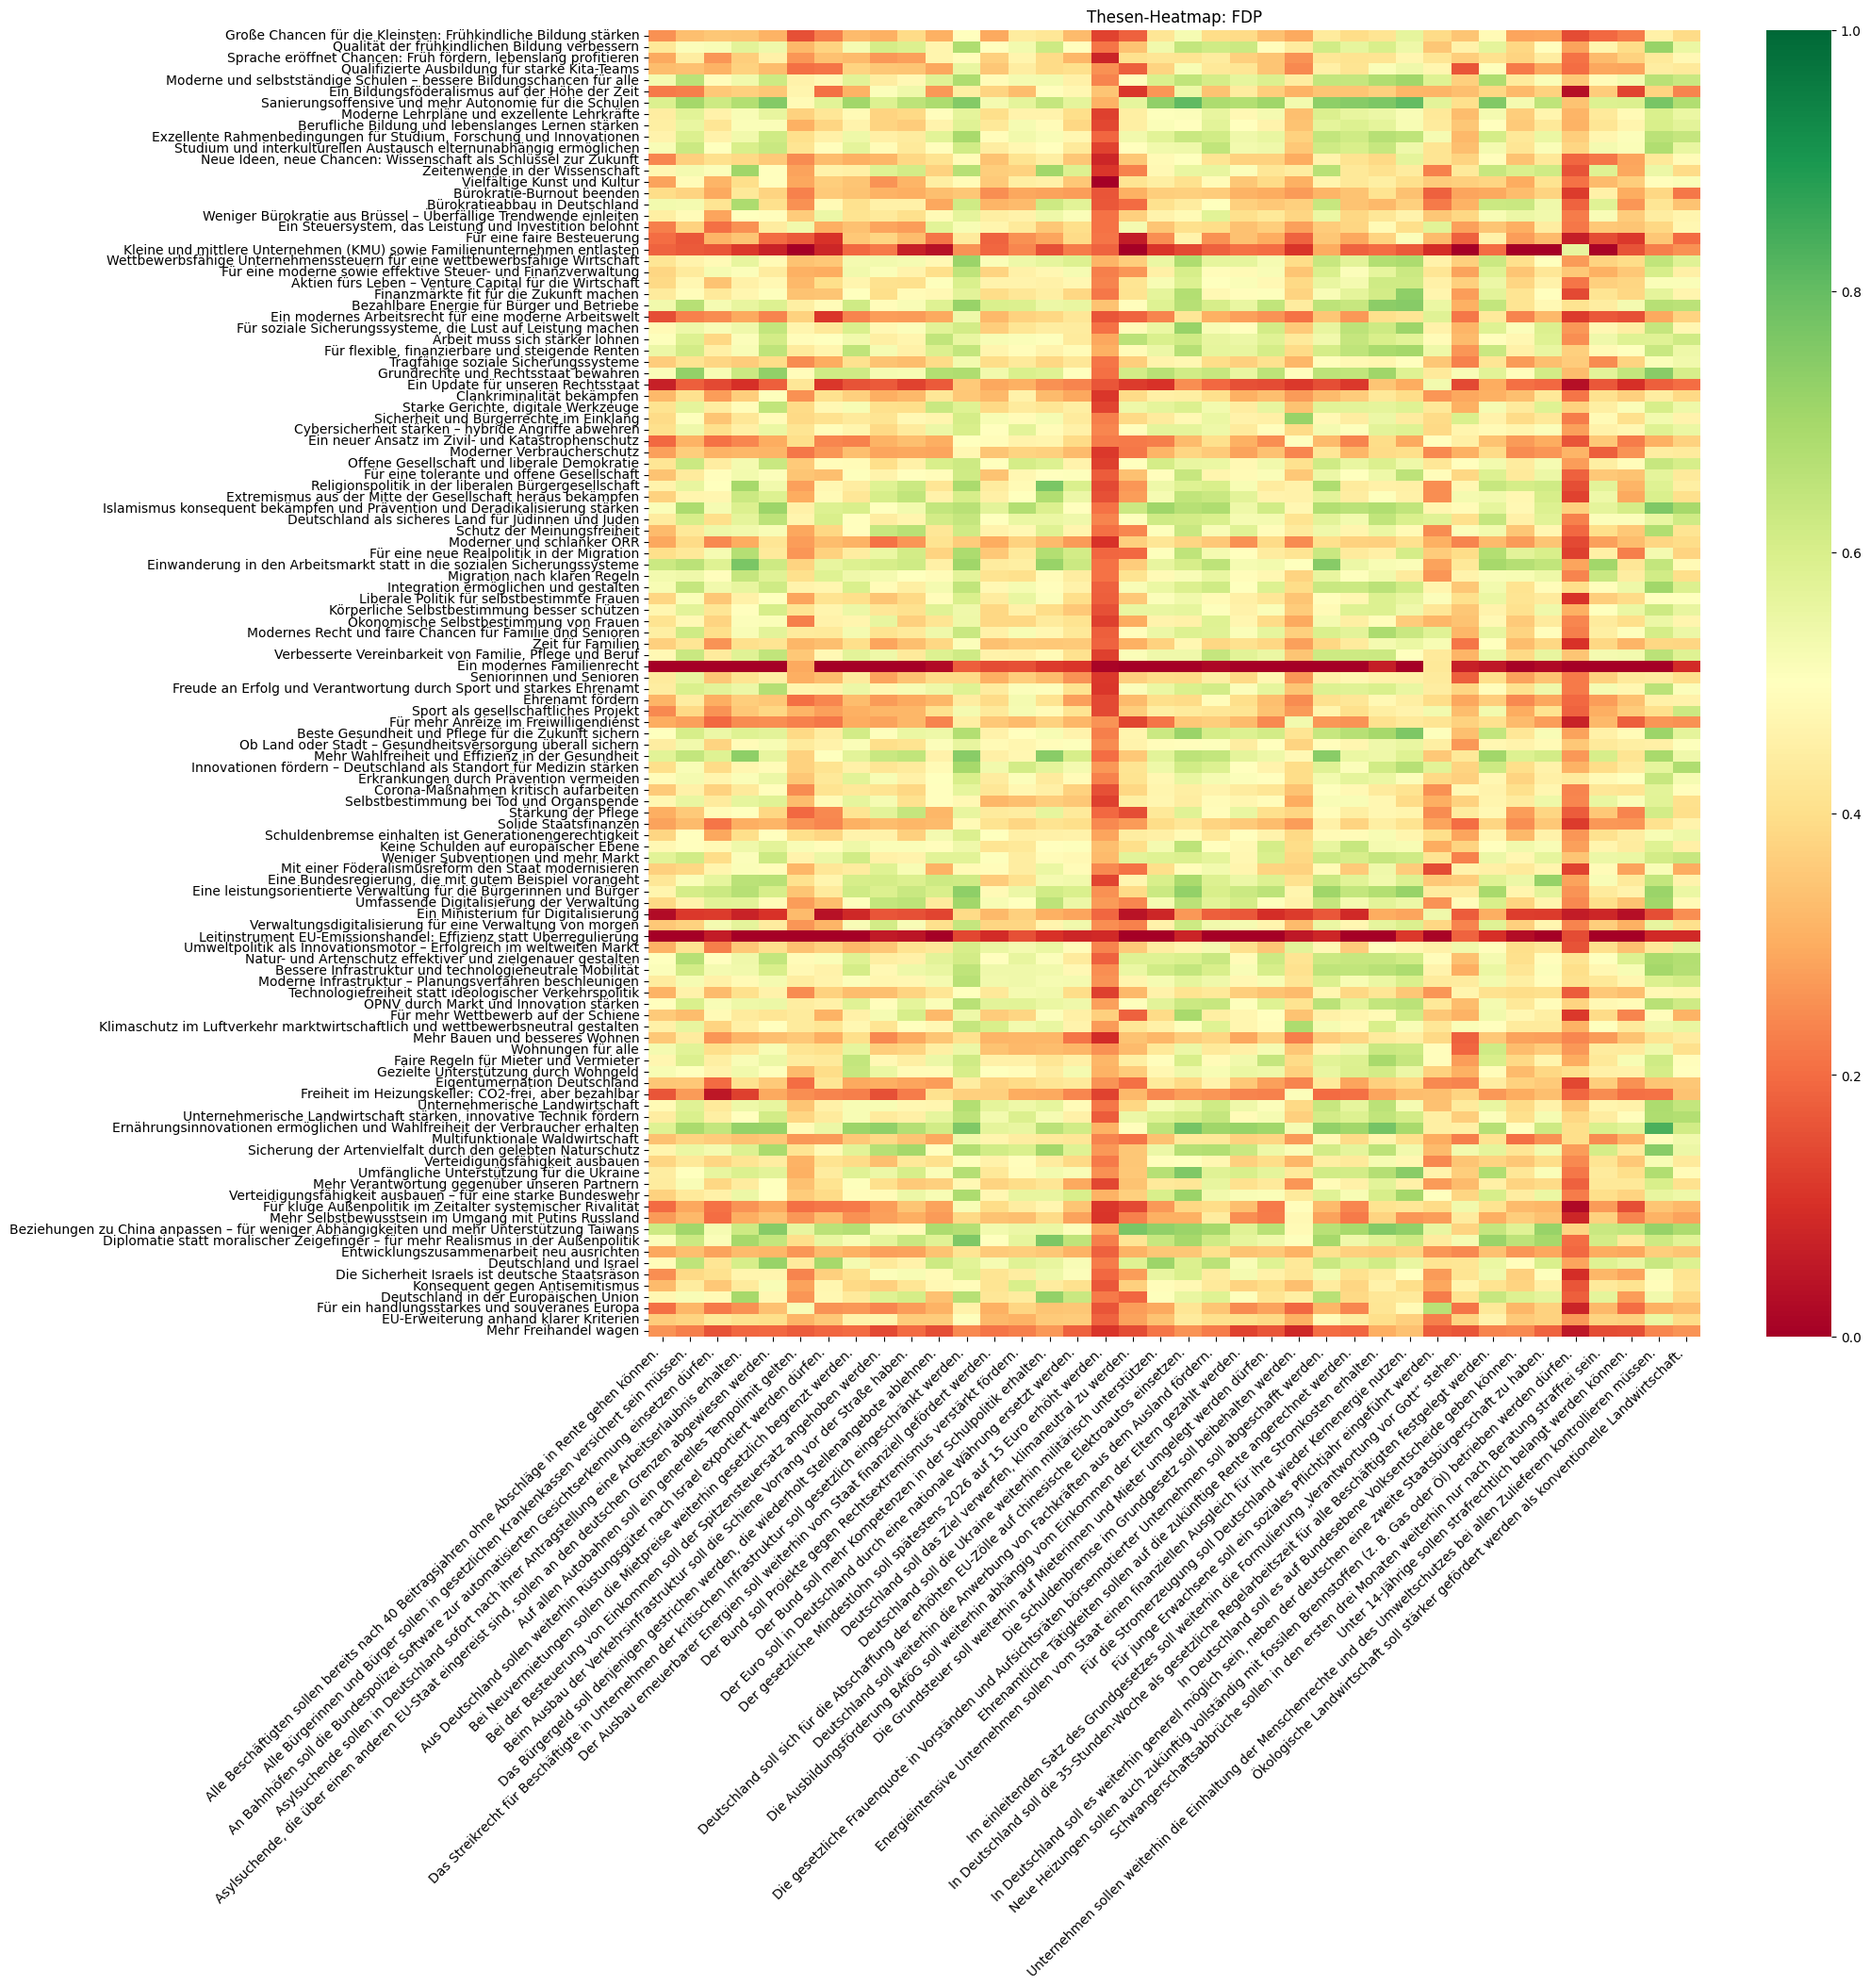

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\1079315963.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


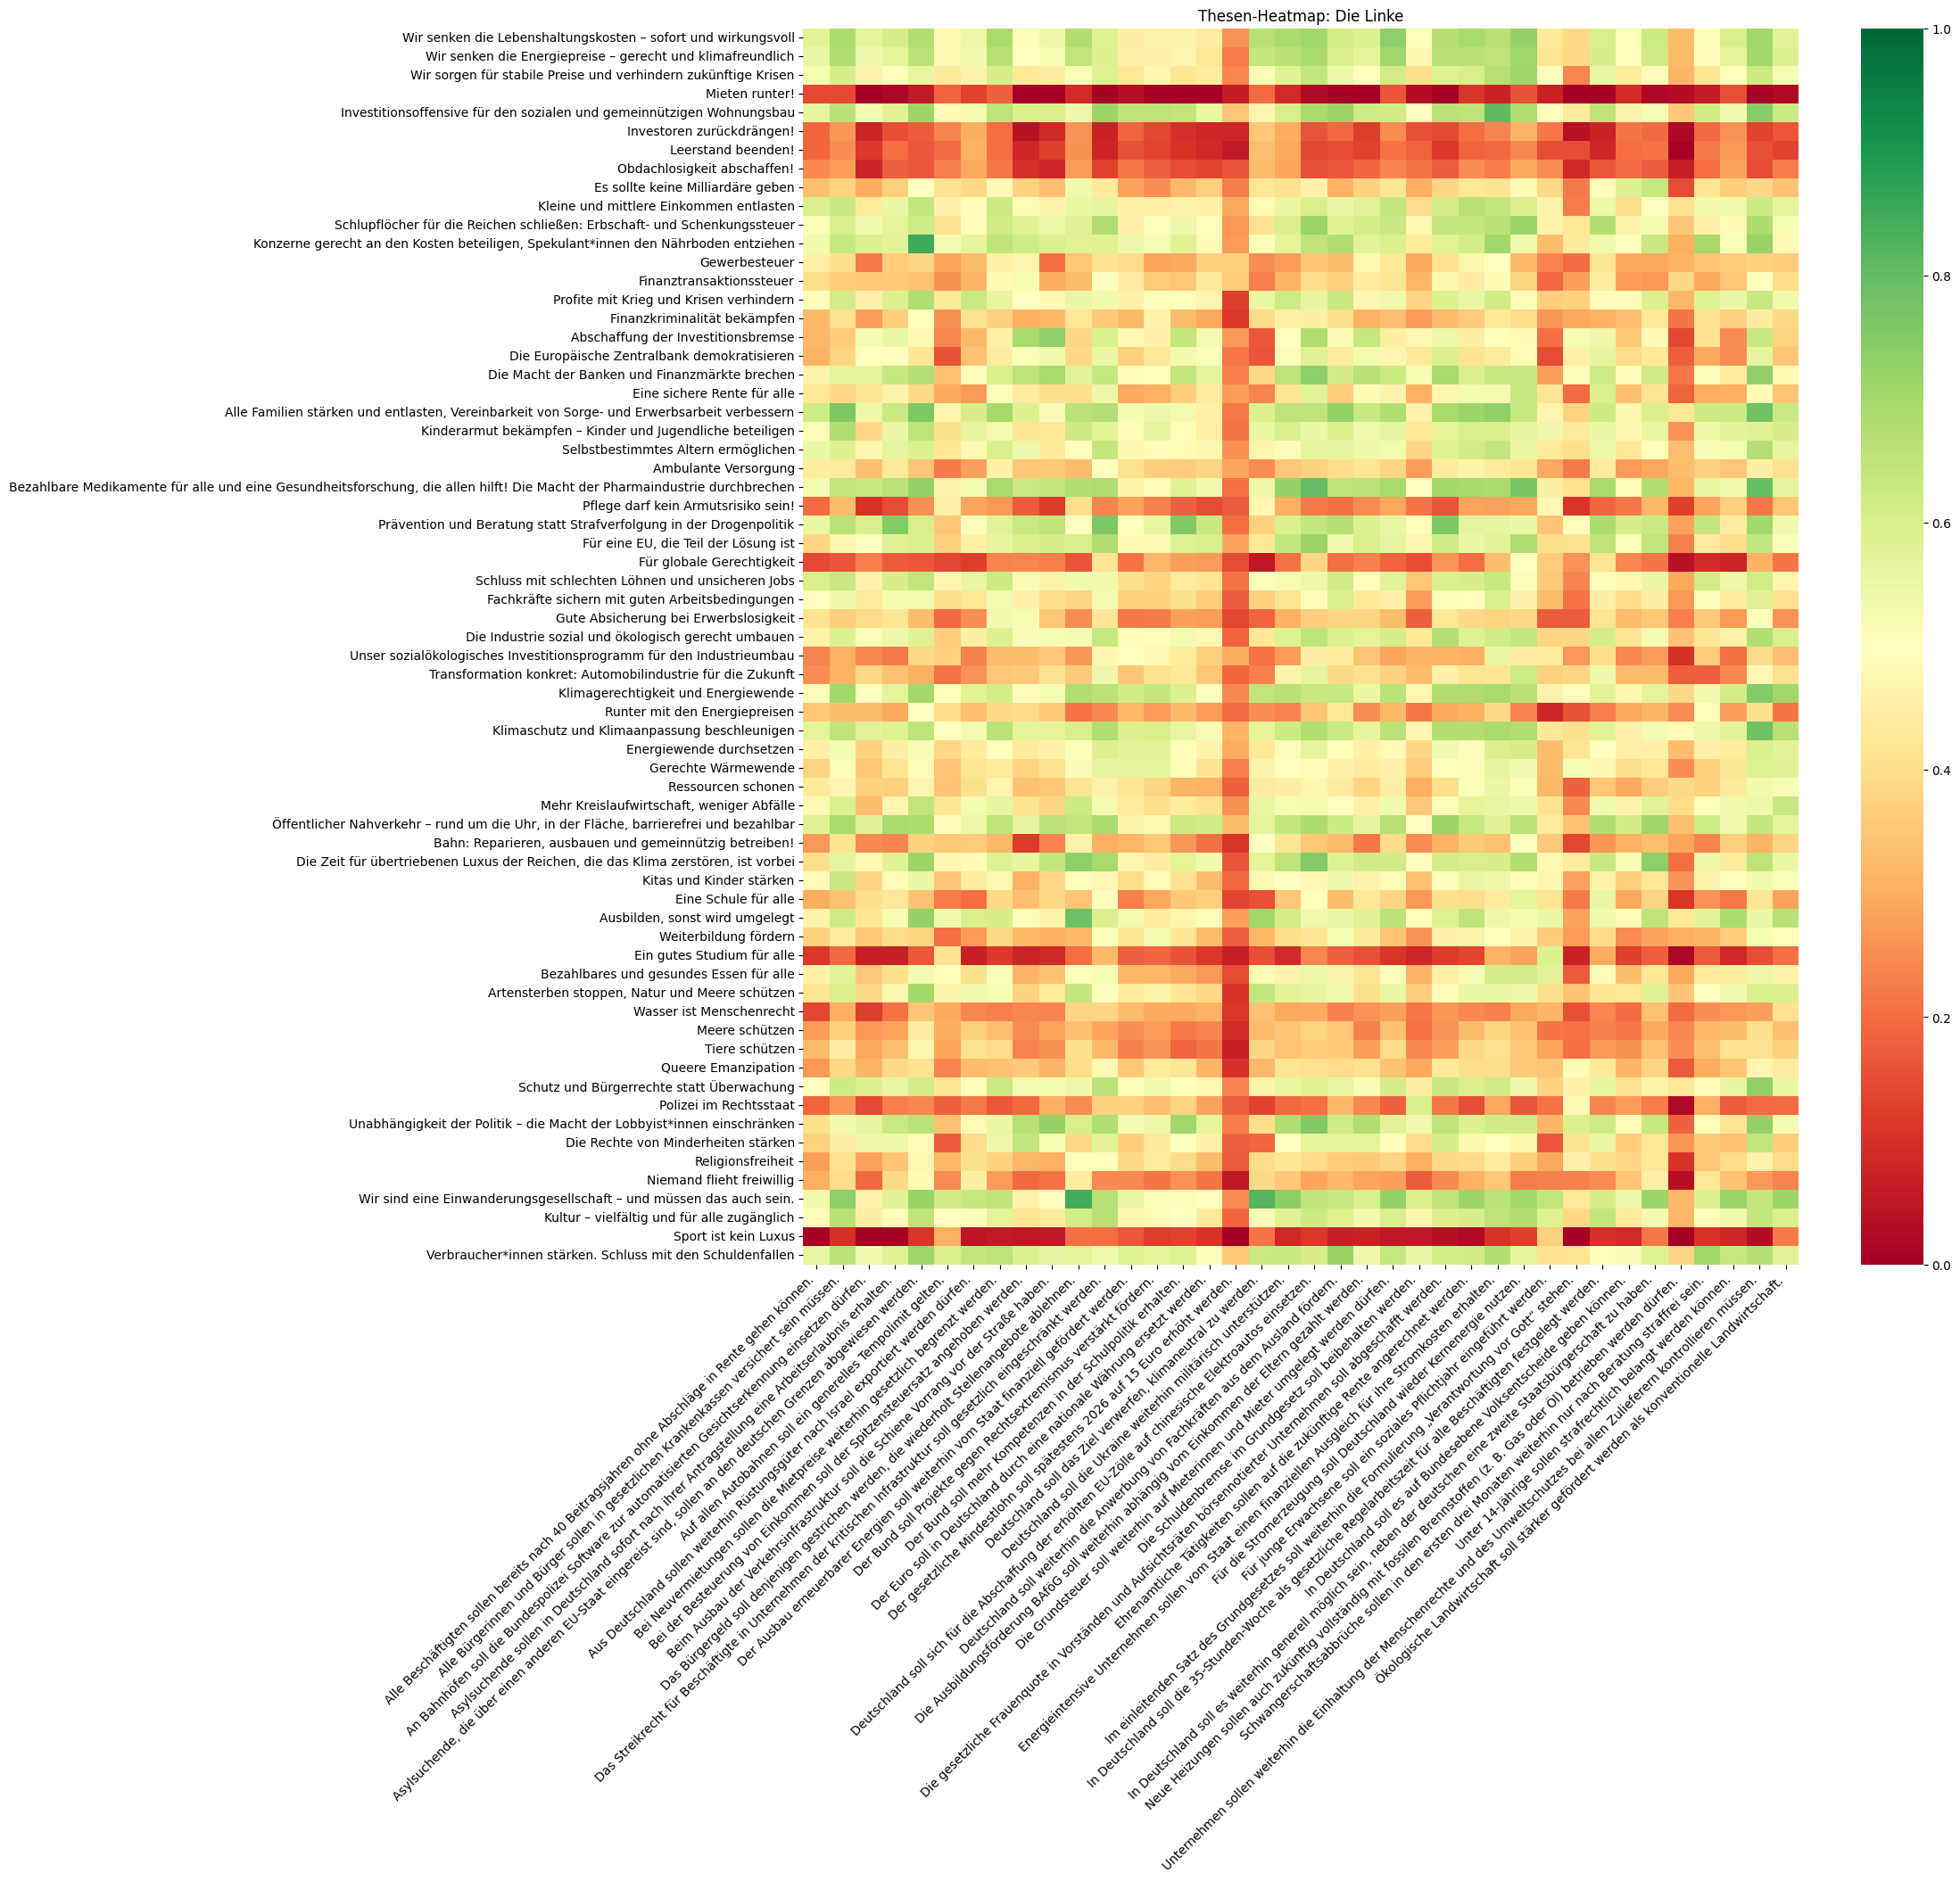

In [93]:

for party_str in parties_list:
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    party_df.dropna(inplace=True)
    party_these_list = party_df['These'].to_list()

    similarity_df = pd.DataFrame(columns=['party_these']+Labled_theses_list)

    for party_these in party_these_list:
        party_these_doc = nlp(party_these)
        row = [party_these]
        for label_these in Labled_theses_list:
            label_these_doc = nlp(label_these)
            similarity_score = party_these_doc.similarity(label_these_doc)
            row = row + [similarity_score]
        similarity_df.loc[len(similarity_df)] = row

    plt.figure(figsize=(18,18))
    sns.heatmap(similarity_df[Labled_theses_list], 
                cmap='RdYlGn', 
                annot= False,
                vmax= 1,
                vmin= 0,
                yticklabels=similarity_df["party_these"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].mean().tolist()


In [94]:
predicted_theses_df

# 0- 0.33       - trifft nicht zu 
# 0.33 - 0.66   - neutral 
# 0.66 - 1.00   - trifft zu

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.383760,0.411345,0.588358,0.376622,0.396876,0.387590
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.502049,0.495558,0.732697,0.455525,0.483452,0.472788
2,An Bahnhöfen soll die Bundespolizei Software z...,0.389396,0.404049,0.551074,0.371030,0.377724,0.394675
3,Asylsuchende sollen in Deutschland sofort nach...,0.458695,0.471594,0.627890,0.453130,0.436151,0.464762
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.532644,0.509184,0.687216,0.470605,0.500670,0.480617
5,Auf allen Autobahnen soll ein generelles Tempo...,0.375236,0.364362,0.538560,0.301598,0.360439,0.343114
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.411350,0.413595,0.632510,0.391842,0.407564,0.386917
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.467581,0.468465,0.651251,0.422645,0.471340,0.448303
8,Bei der Besteuerung von Einkommen soll der Spi...,0.397862,0.416265,0.481508,0.415940,0.407419,0.424328
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.423916,0.428057,0.533175,0.412656,0.404132,0.431598


In [95]:
Labled_theses_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
2,An Bahnhöfen soll die Bundespolizei Software z...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu
3,Asylsuchende sollen in Deutschland sofort nach...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
8,Bei der Besteuerung von Einkommen soll der Spi...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu


C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


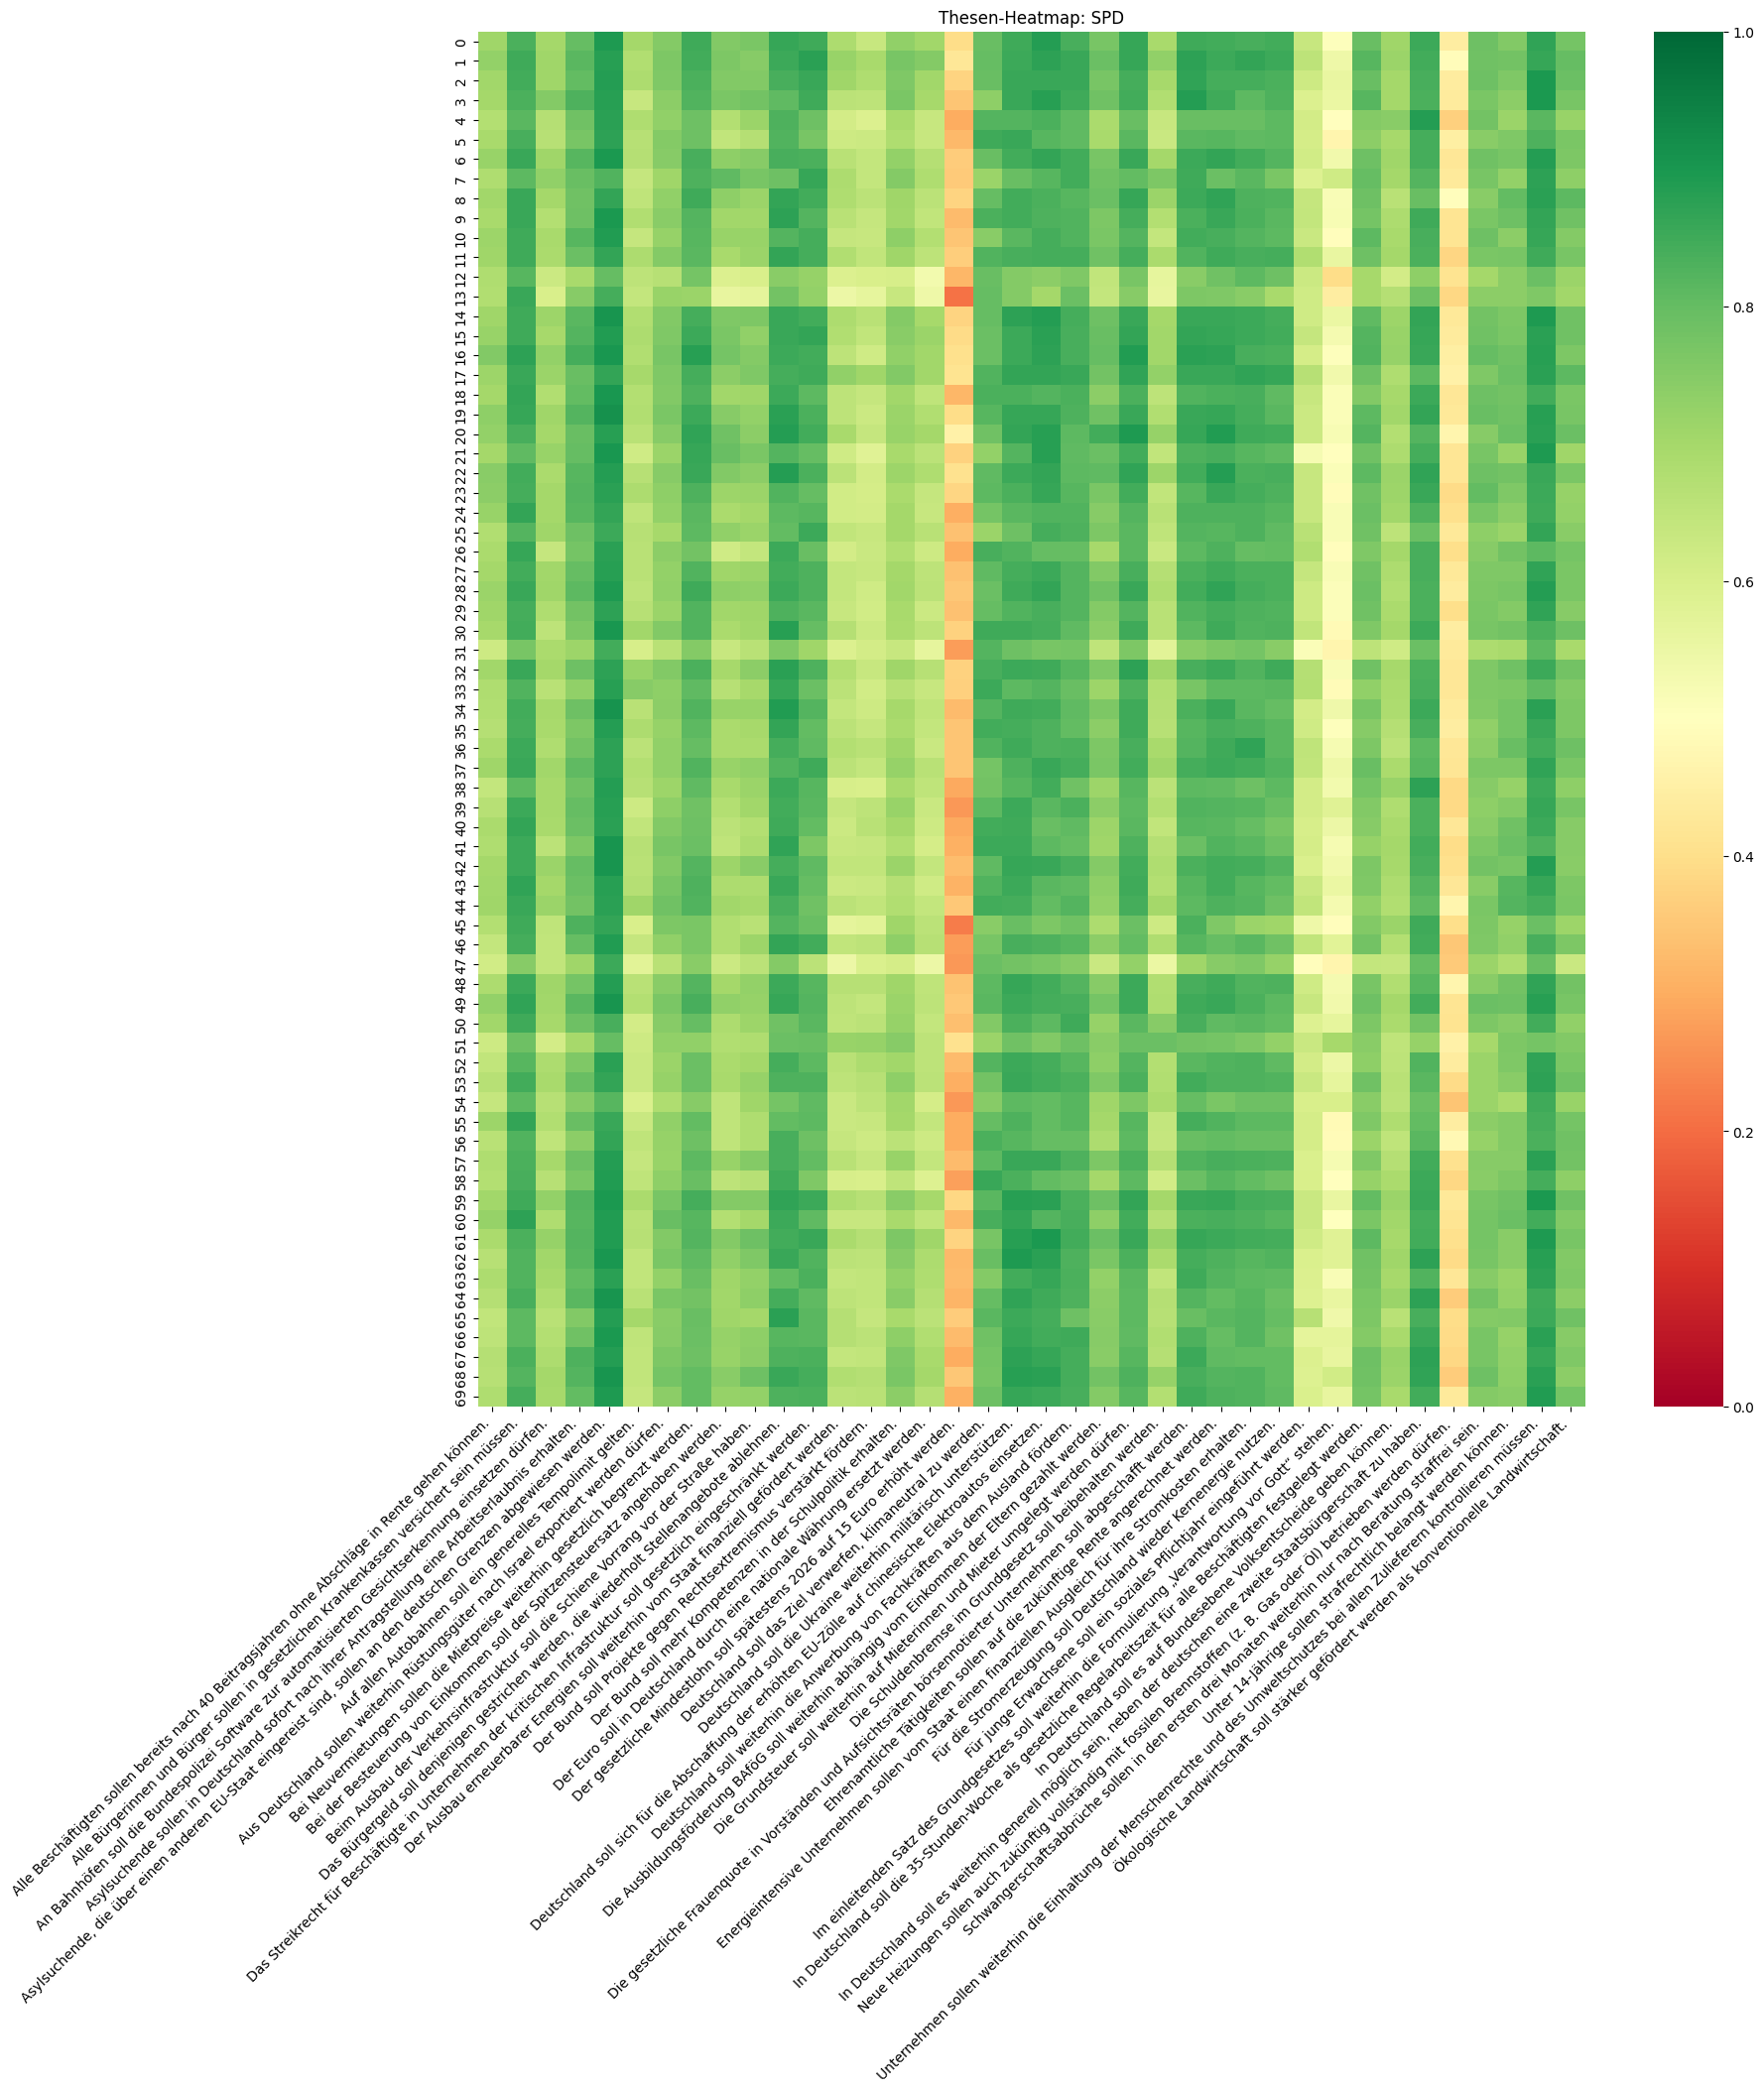

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


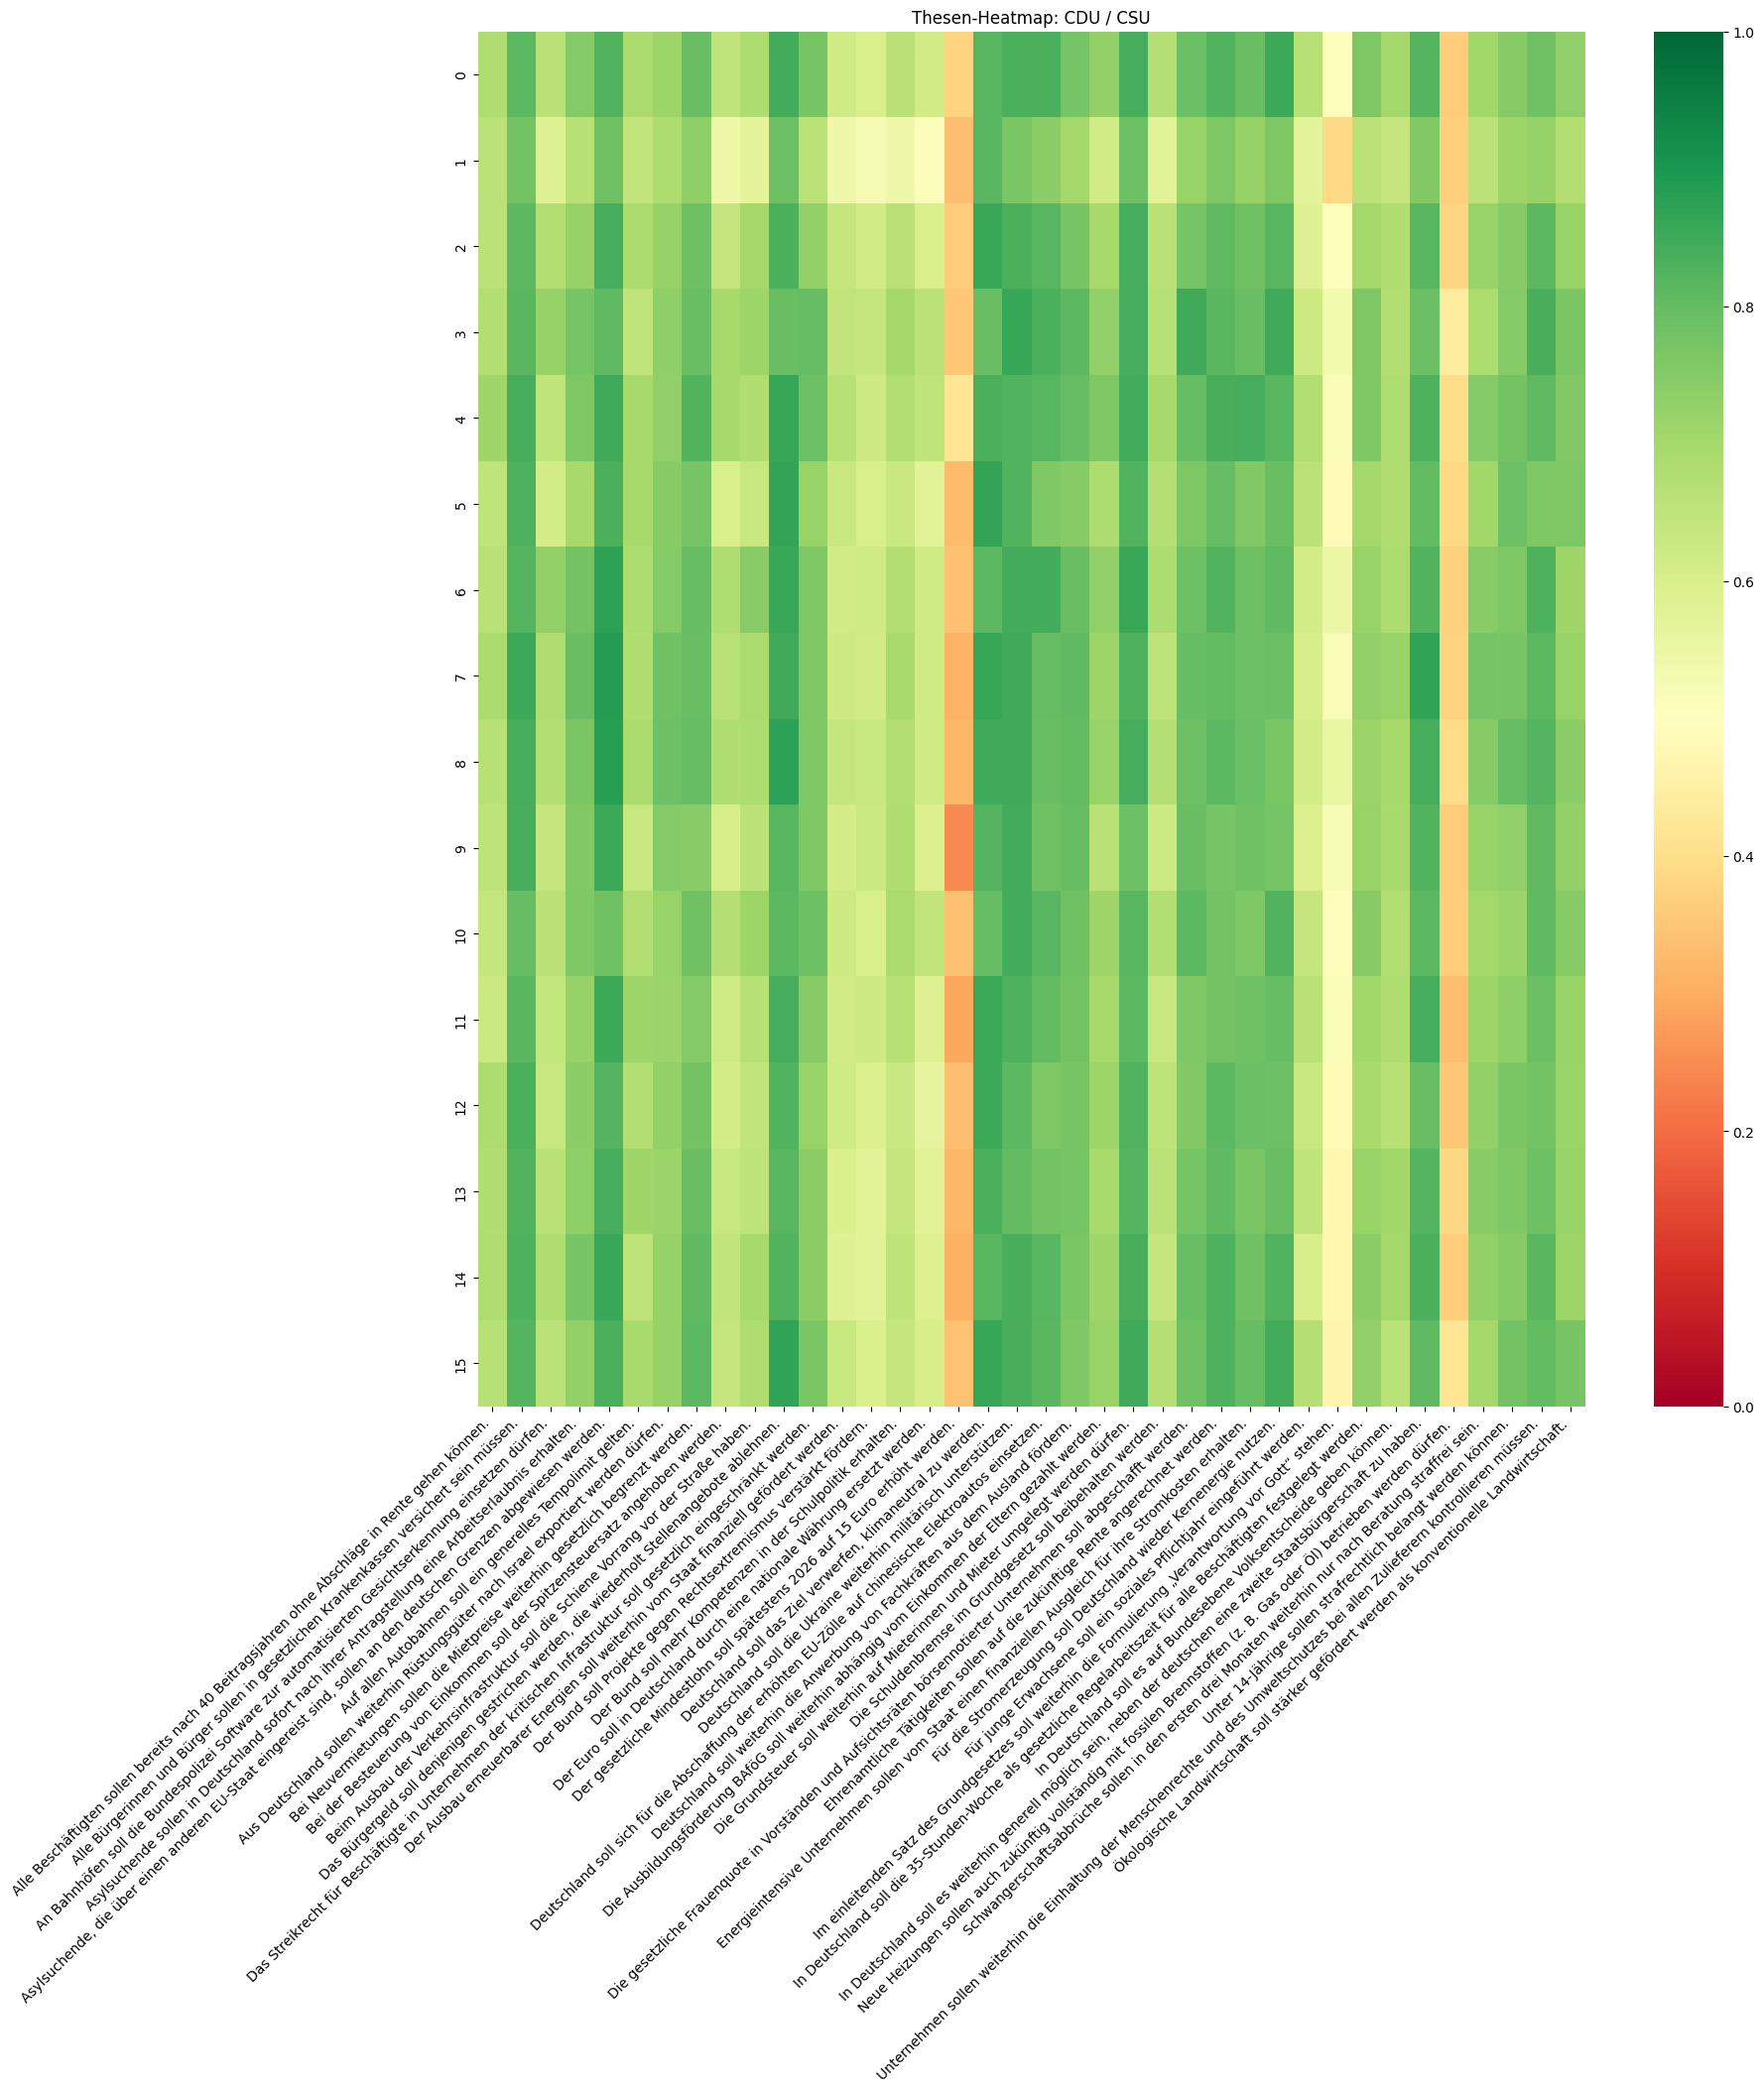

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:13: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:13: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:13: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:13: Use

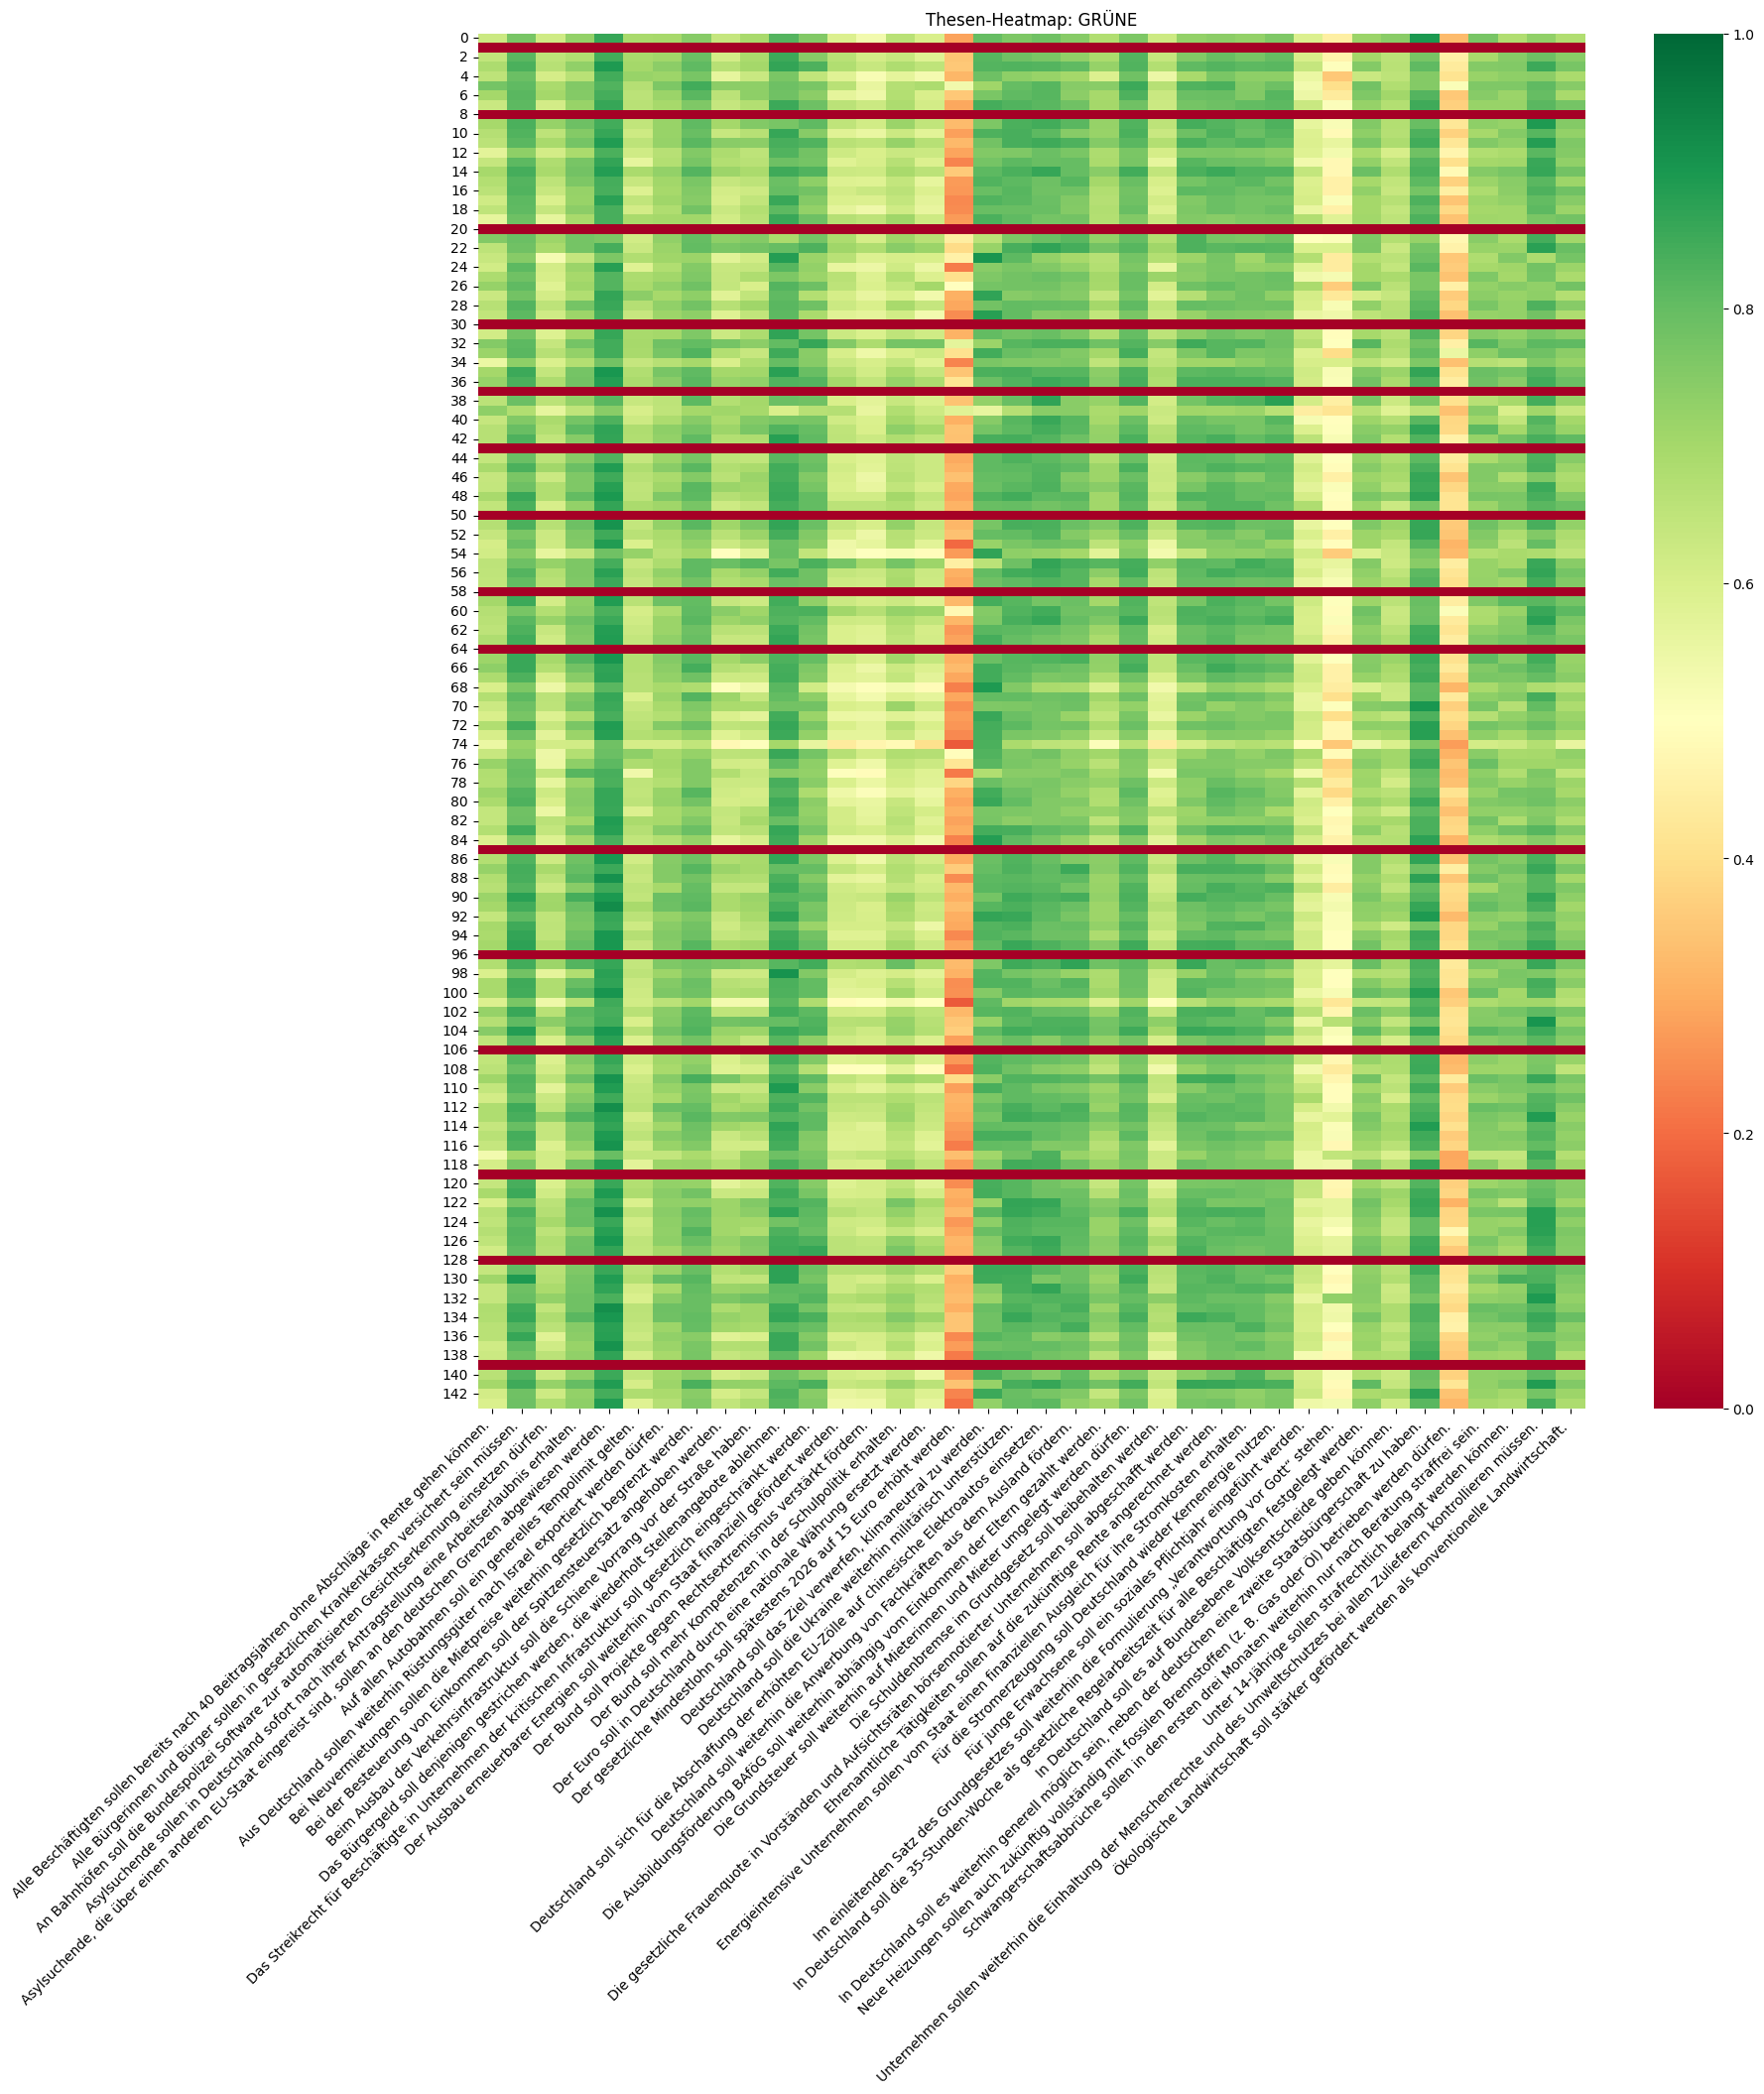

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)
C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:13: UserWarning: [W008] Evaluating Doc.similarity based on empty vectors.
  similarity_score = party_these_doc.similarity(label_these_doc)


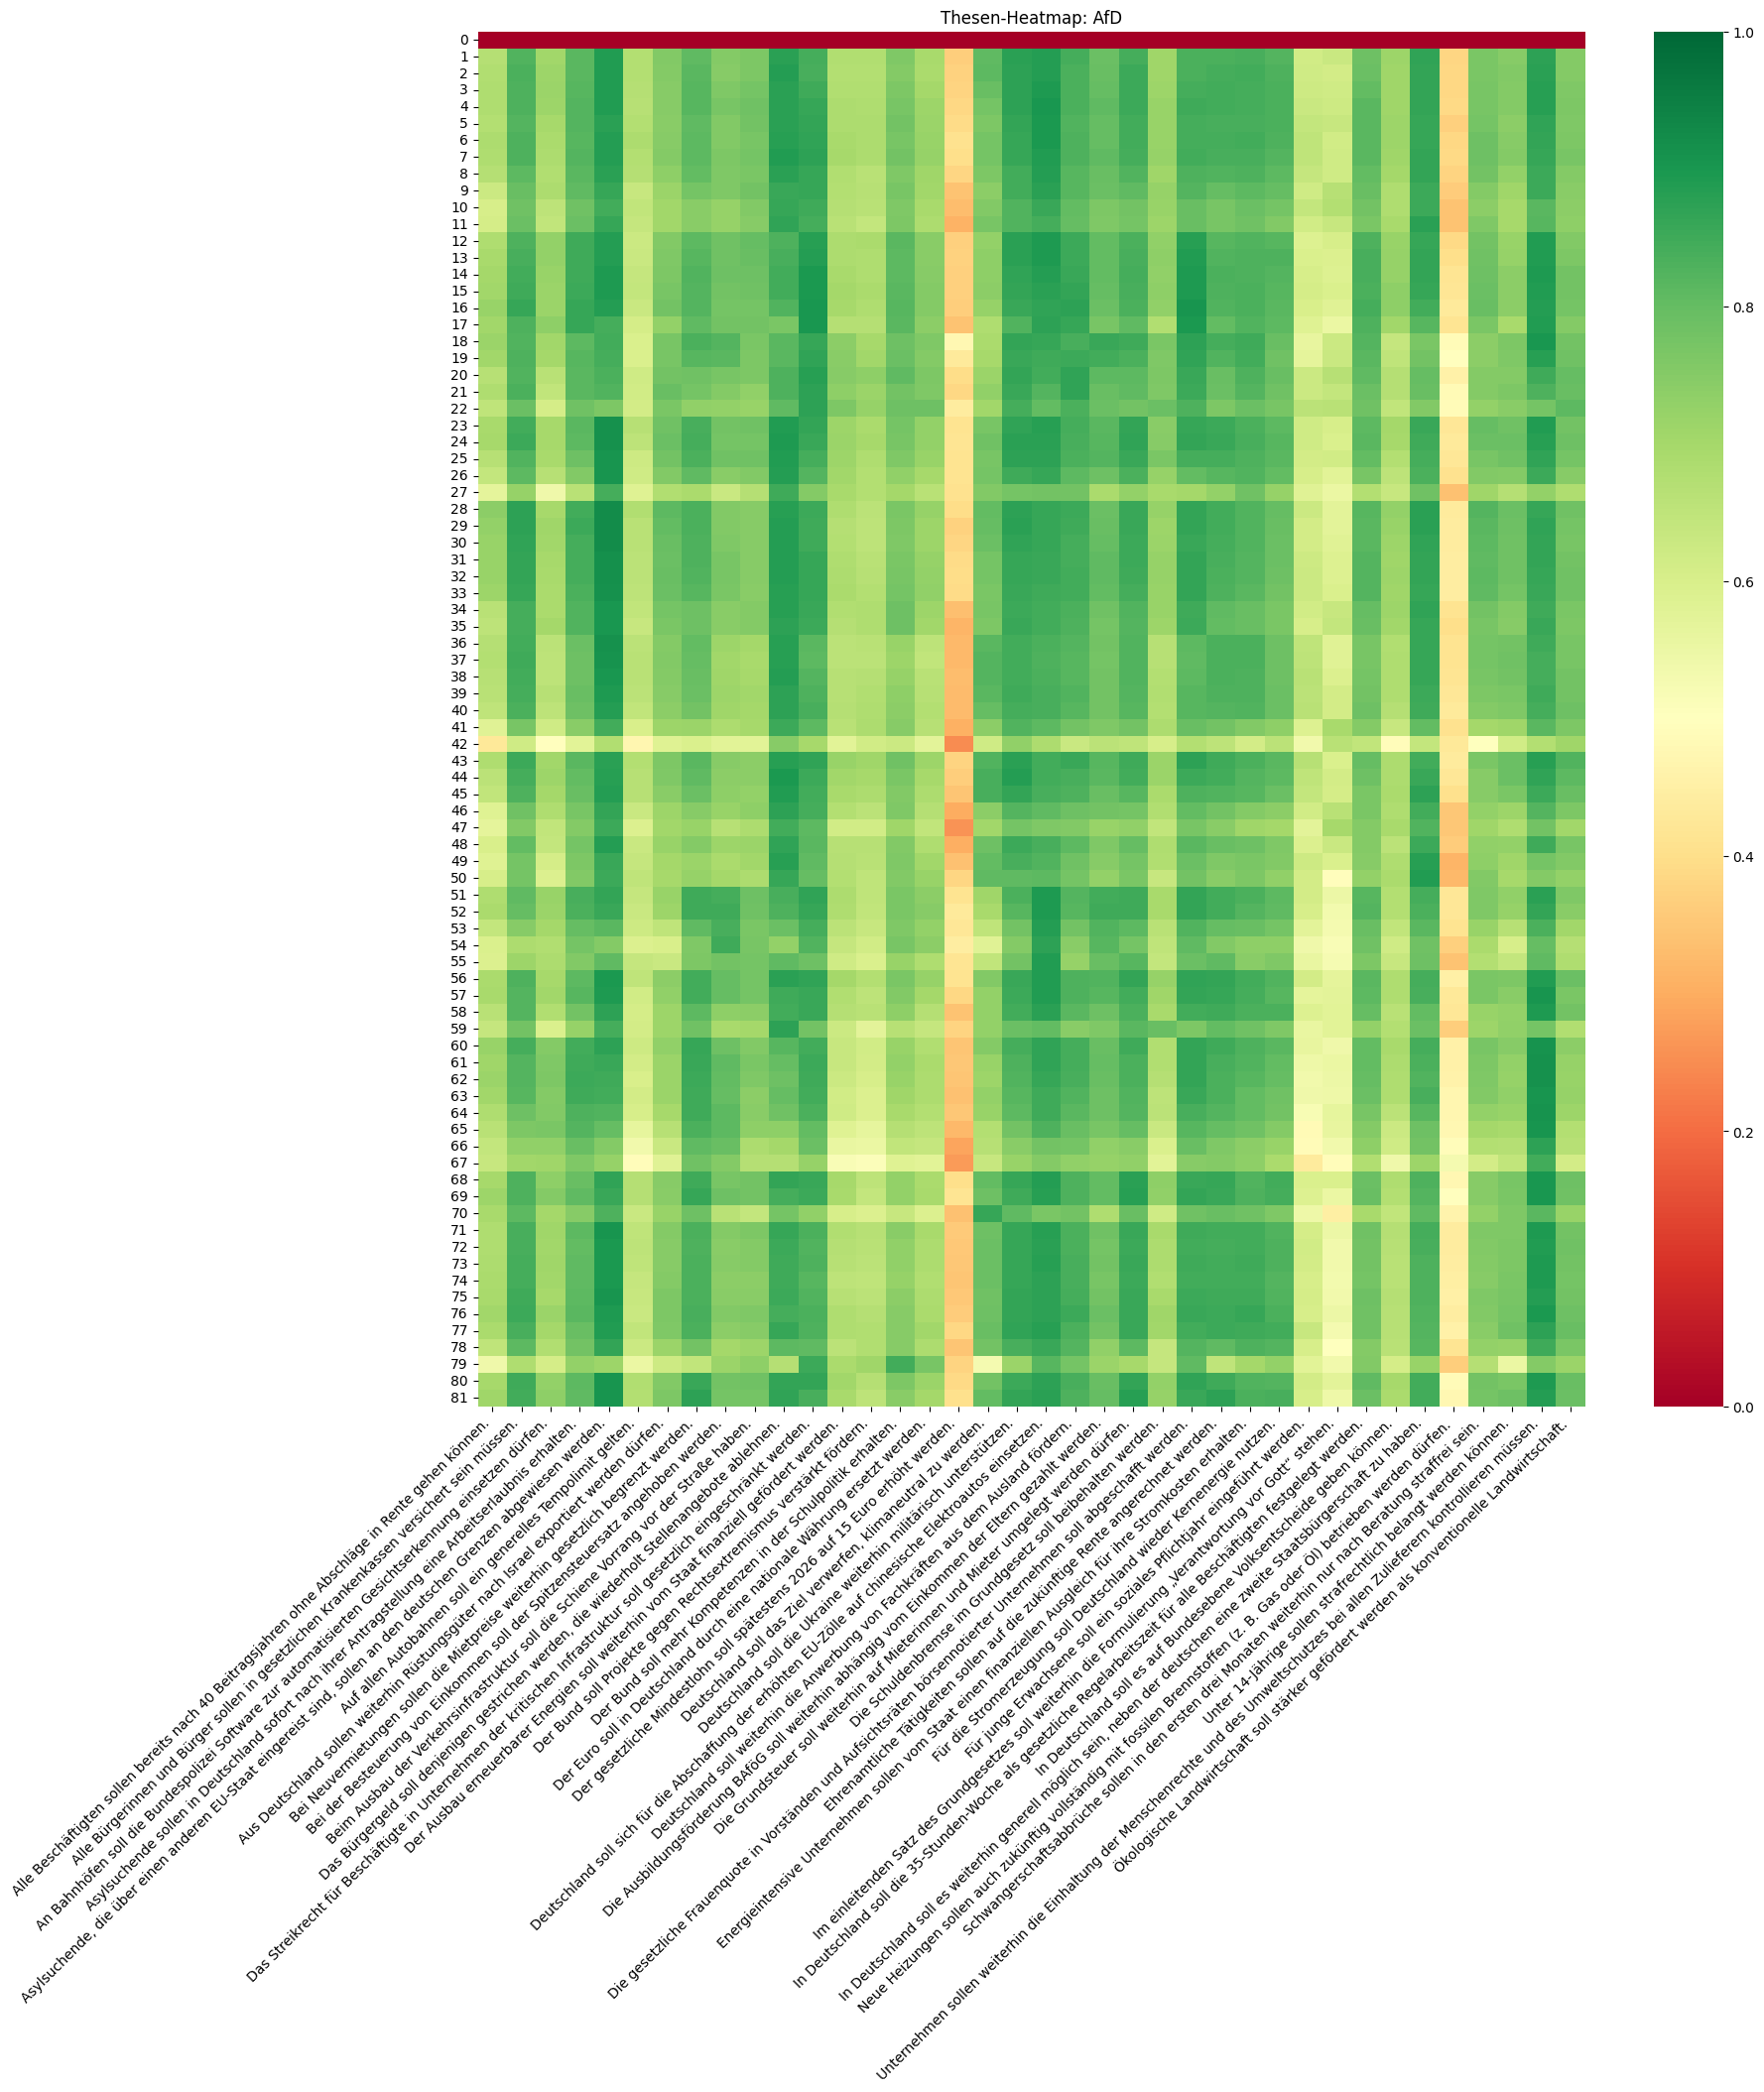

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


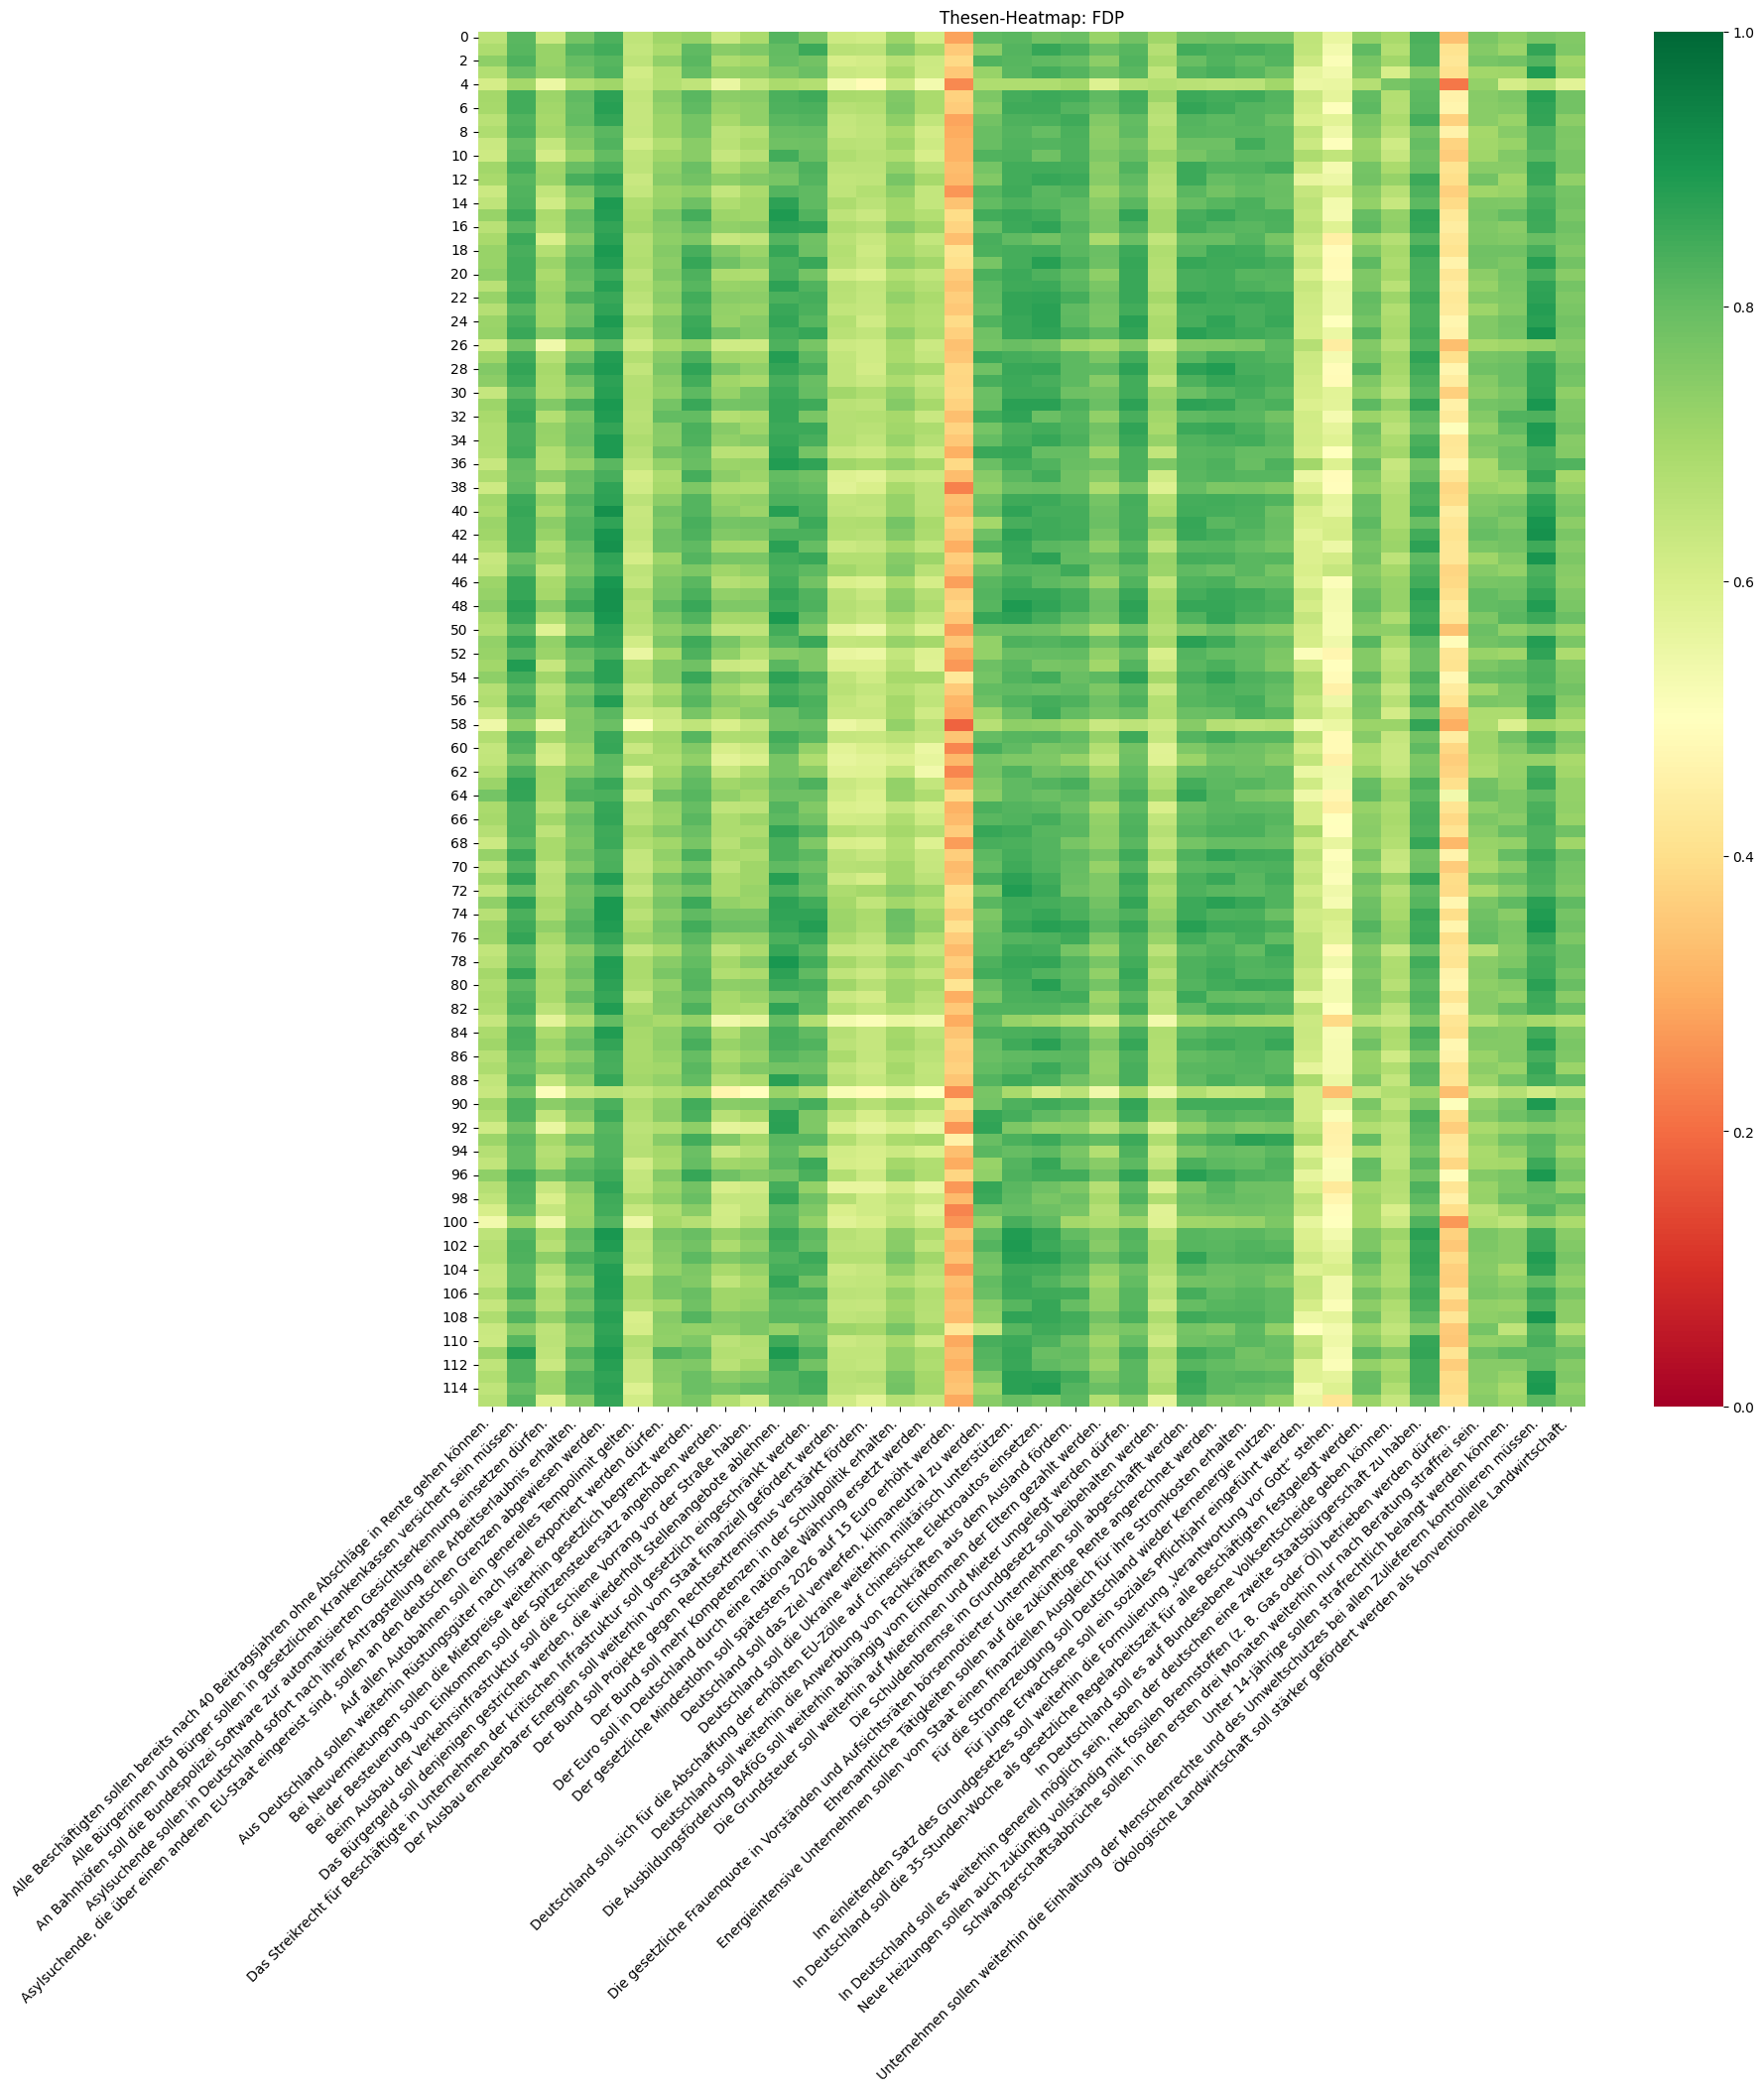

C:\Users\lnieb\AppData\Local\Temp\ipykernel_2656\865680615.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  party_df.dropna(inplace=True)


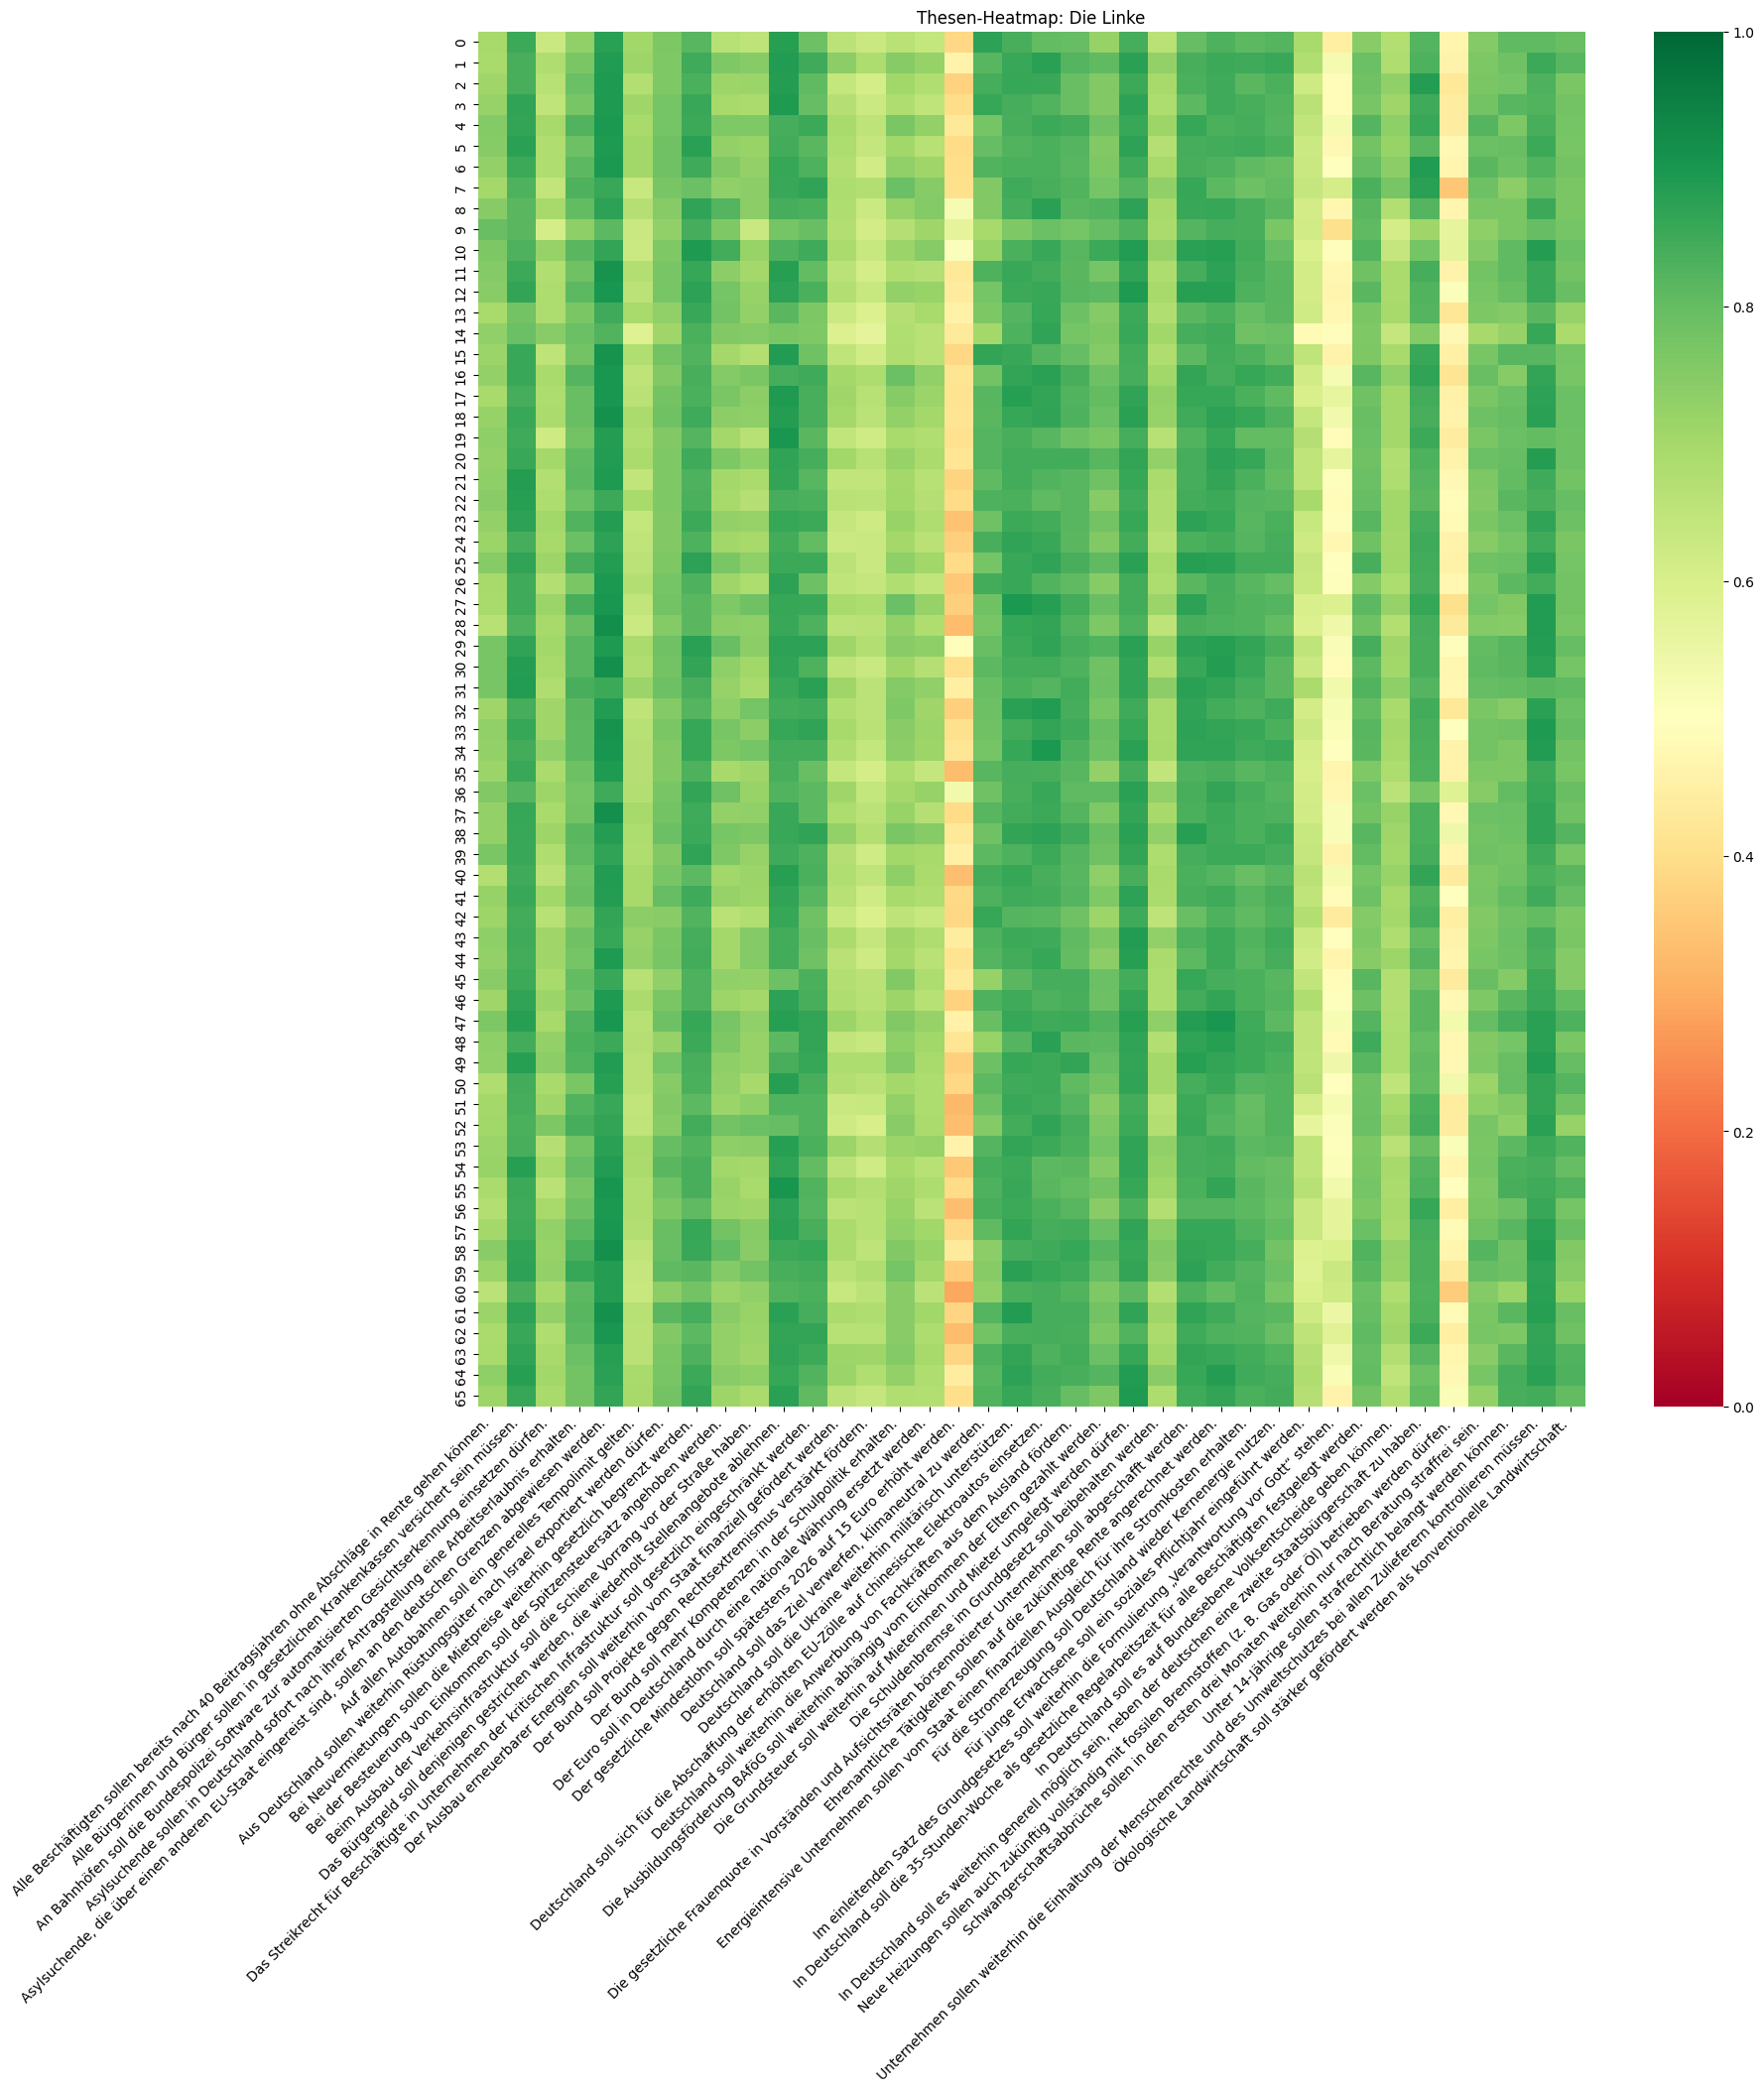

In [97]:
for party_str in parties_list:
    party_df = all_party_textes_df[all_party_textes_df['Party'] == party_str]
    party_df.dropna(inplace=True)
    party_these_list = party_df['Text'].to_list()

    similarity_df = pd.DataFrame(columns=['party_these']+Labled_theses_list)

    for party_these in party_these_list:
        party_these_doc = nlp(party_these)
        row = [party_these]
        for label_these in Labled_theses_list:
            label_these_doc = nlp(label_these)
            similarity_score = party_these_doc.similarity(label_these_doc)
            row = row + [similarity_score]
        similarity_df.loc[len(similarity_df)] = row

    plt.figure(figsize=(18,18))
    sns.heatmap(similarity_df[Labled_theses_list], 
                cmap='RdYlGn', 
                annot= False,
                vmax= 1,
                vmin= 0,
                #yticklabels=similarity_df["party_these"]
                )
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Thesen-Heatmap: {party_str}")
    plt.show()

    predicted_theses_df[party_str] = similarity_df[Labled_theses_list].mean().tolist()

In [98]:
predicted_theses_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,0.667803,0.591395,0.690440,0.657880,0.723209,0.677791
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,0.822905,0.726000,0.840233,0.804710,0.853289,0.826898
2,An Bahnhöfen soll die Bundespolizei Software z...,0.659857,0.575388,0.689113,0.681301,0.693732,0.677322
3,Asylsuchende sollen in Deutschland sofort nach...,0.745870,0.672358,0.789419,0.792572,0.799766,0.779097
4,"Asylsuchende, die über einen anderen EU-Staat ...",0.839076,0.771723,0.878285,0.855748,0.884340,0.859592
5,Auf allen Autobahnen soll ein generelles Tempo...,0.679962,0.579422,0.659348,0.625263,0.673890,0.653930
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,0.733750,0.644311,0.740441,0.726168,0.767678,0.733062
7,Bei Neuvermietungen sollen die Mietpreise weit...,0.786414,0.695441,0.811376,0.792885,0.841403,0.798880
8,Bei der Besteuerung von Einkommen soll der Spi...,0.641448,0.592892,0.705173,0.745411,0.739651,0.696059
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,0.676155,0.606983,0.715953,0.736687,0.723391,0.706570


In [99]:
Labled_theses_df

,These,CDU / CSU,GRÜNE,SPD,AfD,Die Linke,FDP
0,Alle Beschäftigten sollen bereits nach 40 Beit...,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu
1,Alle Bürgerinnen und Bürger sollen in gesetzli...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
2,An Bahnhöfen soll die Bundespolizei Software z...,stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme nicht zu
3,Asylsuchende sollen in Deutschland sofort nach...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,neutral
4,"Asylsuchende, die über einen anderen EU-Staat ...",stimme zu,stimme nicht zu,stimme nicht zu,stimme zu,stimme nicht zu,stimme zu
5,Auf allen Autobahnen soll ein generelles Tempo...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
6,Aus Deutschland sollen weiterhin Rüstungsgüter...,stimme zu,stimme zu,stimme zu,neutral,stimme nicht zu,stimme zu
7,Bei Neuvermietungen sollen die Mietpreise weit...,stimme zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
8,Bei der Besteuerung von Einkommen soll der Spi...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
9,Beim Ausbau der Verkehrsinfrastruktur soll die...,stimme nicht zu,stimme zu,stimme zu,stimme nicht zu,stimme zu,stimme nicht zu
